# 1. Research question

I want to test whether the spatial and hydraulic-system relationships I found in the LIWO data can be turned into a **probabilistic dependence mechanism** for flood-defence breach locations, rather than assuming breaches are independent.

There is an important limitation at the start: the LIWO catalogue I analysed is predominantly made up of single-breach scenarios, so it does not give me enough simultaneous-failure observations to estimate empirical joint breach probabilities directly.

Because of that, I treat the first part of this notebook as a sequence of experiments around a **dependence proxy**. I use the observed spatial and system structure to ask whether a probabilistic mechanism can generate more coherent multi-breach events than an independence baseline. I do not interpret the resulting probabilities as observed joint failure probabilities.


## 2 — Imports and paths

I set up the paths and imports first so the rest of the notebook uses the same processed LIWO data throughout the experiments.


In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## 3 — Load the catalogue

I start from the processed LIWO scenario catalogue because this is the common source for the location, scenario, return-period, system, and damage variables used below.


In [2]:
scenario_path = (
    DATA_DIR
    / "processed"
    / "liwo_scenario_catalog.csv"
)

df = pd.read_csv(scenario_path)

df["damage_MEUR_num"] = pd.to_numeric(
    df["damage_MEUR"],
    errors="coerce"
)

df["return_period"] = pd.to_numeric(
    df["return_period"],
    errors="coerce"
)

df["log_damage"] = np.log1p(
    df["damage_MEUR_num"]
)

print("Rows:", len(df))

Rows: 1856


## 4 — Create the usable breach-location table

I reduce the scenario-level data to one row per breach location for the parts of the analysis that need location-level attributes.

I keep the spatial coordinates and system identifiers because the question here is not only whether two locations are close, but whether they share parts of the same flood-defence system.


In [3]:
locations = (
    df.dropna(
        subset=[
            "geometry_x",
            "geometry_y",
            "river",
            "dijkring"
        ]
    )
    .groupby(
        "breach_id",
        as_index=False
    )
    .agg(
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first"),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        breach_name=("breach_name", "first")
    )
)

print("Breach locations:", len(locations))
print(locations.head())

Breach locations: 619
   breach_id  geometry_x  geometry_y                river  \
0          1       63661      394660        Oosterschelde   
1         14      153030      421657                 Maas   
2         25      157861      425941                 Maas   
3        185      122028      487923       Noordzeekanaal   
4        191      194414      436878  Pannerdensch kanaal   

                                            dijkring           breach_name  
0            Dijkring 27 - Tholen en St. Philipsland  20a_Extrabreslocatie  
1                                 Dijkring 39 - Alem                  Alem  
2                Dijkring 41 - Land van Maas en Waal                Alphen  
3                          Dijkring 44 - Kromme Rijn        Amsterdam zuid  
4  Dijkring 43 - Betuwe, Tieler- en Culemborgerwaard            AngerenARK  


### Estimate each location's scenario frequency

Before constructing pairwise relationships, I check how many scenarios are available for each breach location. I want to know how uneven the catalogue is, because sparse locations can make a pairwise dependence estimate much less stable than it appears from the total number of scenario rows.


In [4]:
scenario_counts = (
    df.dropna(subset=["return_period"])
    .groupby("breach_id")
    .size()
    .rename("n_scenarios")
)

locations = locations.merge(
    scenario_counts,
    on="breach_id",
    how="left"
)

locations["n_scenarios"] = (
    locations["n_scenarios"]
    .fillna(0)
)

print(
    locations["n_scenarios"].describe()
)

count    619.000000
mean       2.998384
std        0.972933
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        8.000000
Name: n_scenarios, dtype: float64


### Build pairwise relationships

I now move from individual breach locations to pairs of locations.

For each pair I calculate distance and retain indicators for shared river and shared dike-ring structure. These are deliberately simple variables: I want to establish whether basic spatial/system relationships contain signal before adding more elaborate features.


In [5]:
coords = locations[
    ["geometry_x", "geometry_y"]
].to_numpy()

n = len(locations)

distance_matrix = np.sqrt(
    (
        coords[:, None, :]
        - coords[None, :, :]
    ) ** 2
).sum(axis=2) ** 0.5

In [6]:
pair_rows = []

for i in range(n):

    for j in range(i + 1, n):

        pair_rows.append({
            "breach_i": locations.iloc[i]["breach_id"],
            "breach_j": locations.iloc[j]["breach_id"],

            "distance_km":
                distance_matrix[i, j] / 1000,

            "same_river": int(
                locations.iloc[i]["river"]
                == locations.iloc[j]["river"]
            ),

            "same_dijkring": int(
                locations.iloc[i]["dijkring"]
                == locations.iloc[j]["dijkring"]
            ),

            "scenario_count_i":
                locations.iloc[i]["n_scenarios"],

            "scenario_count_j":
                locations.iloc[j]["n_scenarios"]
        })

pairs = pd.DataFrame(pair_rows)

print("Unique location pairs:", len(pairs))
print(pairs.head())

Unique location pairs: 191271
   breach_i  breach_j  distance_km  same_river  same_dijkring  \
0         1        14     0.341125           0              0   
1         1        25     0.354233           0              0   
2         1       185     0.389397           0              0   
3         1       191     0.415898           0              0   
4         1       205     0.371051           0              0   

   scenario_count_i  scenario_count_j  
0                 1                 3  
1                 1                 3  
2                 1                 2  
3                 1                 3  
4                 1                 3  


### Construct a dependence proxy

The LIWO data do not directly tell me whether two breach locations fail jointly. I therefore need an observable quantity that can act as a proxy for whether two locations have similar flood consequences.

Here I use the difference in their location-level log damage. Smaller differences mean more similar consequences. I treat this as a modelling proxy, not as a measurement of joint breach probability.


In [7]:
location_damage = (
    df.dropna(
        subset=[
            "log_damage",
            "breach_id"
        ]
    )
    .groupby("breach_id")["log_damage"]
    .mean()
    .rename("mean_log_damage")
)

locations = locations.merge(
    location_damage,
    on="breach_id",
    how="left"
)

In [8]:
damage_lookup = locations.set_index(
    "breach_id"
)["mean_log_damage"]

pairs["log_damage_difference"] = (
    pairs["breach_i"]
    .map(damage_lookup)
    -
    pairs["breach_j"]
    .map(damage_lookup)
).abs()

print(
    pairs[
        [
            "distance_km",
            "same_river",
            "same_dijkring",
            "log_damage_difference"
        ]
    ].head()
)

   distance_km  same_river  same_dijkring  log_damage_difference
0     0.341125           0              0               1.484435
1     0.354233           0              0               2.027481
2     0.389397           0              0               4.044696
3     0.415898           0              0               4.634178
4     0.371051           0              0               3.210992


## Building the first probabilistic relationship model

I first turn the continuous consequence-similarity measure into a binary indicator for a simple experiment: can distance, river membership, and dike-ring membership explain which pairs have relatively similar consequences?

This is intentionally a first model. I want to see how much structure is available from a small set of interpretable variables before moving to richer models.


In [9]:
threshold = pairs[
    "log_damage_difference"
].quantile(0.25)

pairs["high_similarity"] = (
    pairs["log_damage_difference"]
    <= threshold
).astype(int)

print("Similarity threshold:", threshold)

print(
    pairs["high_similarity"]
    .value_counts(normalize=True)
)

Similarity threshold: 1.130295054854006
high_similarity
0    0.757219
1    0.242781
Name: proportion, dtype: float64


In [10]:
import statsmodels.formula.api as smf

dependence_model = smf.logit(
    """
    high_similarity
    ~ np.log1p(distance_km)
    + same_river
    + same_dijkring
    """,
    data=pairs
).fit(
    disp=False
)

print(dependence_model.summary())

                           Logit Regression Results                           
Dep. Variable:        high_similarity   No. Observations:               191271
Model:                          Logit   Df Residuals:                   191267
Method:                           MLE   Df Model:                            3
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.007375
Time:                        15:50:39   Log-Likelihood:            -1.0523e+05
converged:                       True   LL-Null:                   -1.0601e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.8393      0.019    -45.123      0.000      -0.876      -0.803
np.log1p(distance_km)    -1.1870      0.061    -19.327      0.000      -1.307      -1.067
same_riv

In [11]:
print(
    dependence_model.params
)

print(
    dependence_model.conf_int()
)

Intercept               -0.839332
np.log1p(distance_km)   -1.186965
same_river               0.286924
same_dijkring            0.529496
dtype: float64
                              0         1
Intercept             -0.875790 -0.802875
np.log1p(distance_km) -1.307334 -1.066595
same_river             0.239729  0.334120
same_dijkring          0.471046  0.587945


In [12]:
odds_ratios = np.exp(
    dependence_model.params
)

odds_ratio_ci = np.exp(
    dependence_model.conf_int()
)

print(
    pd.DataFrame({
        "odds_ratio": odds_ratios,
        "CI_low": odds_ratio_ci[0],
        "CI_high": odds_ratio_ci[1]
    })
)

                       odds_ratio    CI_low   CI_high
Intercept                0.431999  0.416533  0.448039
np.log1p(distance_km)    0.305146  0.270540  0.344178
same_river               1.332323  1.270904  1.396711
same_dijkring            1.698076  1.601669  1.800286


## Continuous spatial similarity model — Random Forest

The binary formulation is useful for a first test, but the underlying damage-similarity measure is continuous. I therefore also test a regression formulation.

I use a Random Forest because it can capture nonlinear interactions without requiring me to specify the functional form in advance. At this stage I am testing whether spatial/system information has predictive value, not assuming that the model itself is the final dependence mechanism.


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pairs_cont = pairs.dropna(
    subset=[
        "distance_km",
        "same_river",
        "same_dijkring",
        "log_damage_difference"
    ]
).copy()

# Continuous similarity
pairs_cont["similarity"] = np.exp(
    -pairs_cont["log_damage_difference"]
)

features = [
    "distance_km",
    "same_river",
    "same_dijkring"
]

X = pairs_cont[features]
y = pairs_cont["similarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

similarity_rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

similarity_rf.fit(
    X_train,
    y_train
)

pred = similarity_rf.predict(X_test)

print("Similarity RF")
print("MAE :", mean_absolute_error(y_test, pred))
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_test, pred)
    )
)
print("R²  :", r2_score(y_test, pred))

Similarity RF
MAE : 0.20766647827390178
RMSE: 0.2658656410259223
R²  : -0.054546529986137404


## What this first model tells me

The first models do not explain a large share of the variation. I interpret that as evidence that I have compressed a complicated flood-consequence relationship into only a few pairwise variables:

$$S_{ij}=f(d_{ij}, river_{ij}, dike_{ij})$$

That is useful diagnostically. Consequence similarity can also depend on exposure, hydraulic conditions, breach characteristics and broader neighbourhood structure, none of which is represented fully here.

This is the point where I start looking beyond distance and simple system membership rather than treating a weak first model as evidence that spatial dependence is absent.


## Building an independence event generator

I first need a reference point for event generation. Under the independence assumption, a candidate breach is sampled without conditioning on the previously selected breach locations.

I then introduce a dependence adjustment to ask a separate question: what changes when the probability of selecting a candidate depends on its relationship to an already selected breach?

The formulation is:

$$P(B_i=1,B_j=1)=p_i p_j$$

for the independence benchmark, and for the dependent case:

$$
P(B_j=1\mid B_i=1)
=
\operatorname{logit}^{-1}
\left[
\operatorname{logit}(p_j)+\theta_{ij}
\right]
$$

where the pairwise adjustment is based on distance, river membership and dike-ring membership.

At this stage this is a **scenario-generation mechanism**, not an estimate of empirical joint failure probability.


In [14]:
# Baseline scenario coverage by breach location

location_scenarios = (
    df.dropna(
        subset=["return_period"]
    )
    .groupby("breach_id")
    .agg(
        n_scenarios=("scenario_id", "nunique"),
        min_return_period=("return_period", "min"),
        max_return_period=("return_period", "max")
    )
    .reset_index()
)

print(location_scenarios.describe())

print("\nScenario-count distribution:")
print(
    location_scenarios["n_scenarios"]
    .value_counts()
    .sort_index()
)

         breach_id  n_scenarios  min_return_period  max_return_period
count   619.000000   619.000000       6.190000e+02       6.190000e+02
mean   2056.339257     2.998384       1.813552e+04       2.585766e+05
std     979.049455     0.972933       1.760325e+05       3.222011e+05
min       1.000000     1.000000      -9.999000e+03      -9.999000e+03
25%    1110.500000     3.000000       2.000000e+02       1.250000e+04
50%    2252.000000     3.000000       1.000000e+03       2.000000e+05
75%    2986.500000     4.000000       4.000000e+03       4.000000e+05
max    3475.000000     8.000000       4.000000e+06       4.000000e+06

Scenario-count distribution:
n_scenarios
1     59
2     84
3    297
4    163
5     13
6      1
7      1
8      1
Name: count, dtype: int64


In [18]:
valid_rps = [
    125, 200, 400, 1000, 1250, 2000, 4000,
    10000, 12500, 20000, 40000, 100000,
    200000, 400000, 1000000
]

In [19]:
rp_location_counts = (
    df[
        df["return_period"].isin(valid_rps)
    ]
    .groupby("return_period")["breach_id"]
    .nunique()
    .sort_index()
)

print(rp_location_counts)

return_period
125         99
200         53
400        141
1000        34
1250       124
2000       118
4000       278
10000       79
12500       98
20000       87
40000      267
100000      56
200000      48
400000     222
1000000     51
Name: breach_id, dtype: int64


### Calculate annual-exceedance frequency

I calculate annual-exceedance quantities here to keep the return-period conditioning explicit. The purpose is to make sure the event-generation experiments are tied to the hydraulic forcing level rather than treating all scenarios as interchangeable.


In [20]:
# Use only valid return periods
scenario_freq = df[
    df["return_period"].isin(valid_rps)
].copy()

scenario_freq["annual_exceedance_frequency"] = (
    1.0 / scenario_freq["return_period"].astype(float)
)

scenario_freq[
    [
        "breach_id",
        "scenario_id",
        "return_period",
        "annual_exceedance_frequency"
    ]
].head(20)

,breach_id,scenario_id,return_period,annual_exceedance_frequency
0,1,15121,400000,0.000003
1,14,19091,125,0.008000
2,14,19092,1250,0.000800
3,14,19093,12500,0.000080
4,25,5214,125,0.008000
5,25,5308,1250,0.000800
6,25,5213,12500,0.000080
7,185,18312,10000,0.000100
8,185,18313,100000,0.000010
9,191,19035,125,0.008000


In [21]:
print(
    scenario_freq[
        "annual_exceedance_frequency"
    ].describe()
)

count    1818.000000
mean        0.000950
std         0.001987
min         0.000001
25%         0.000025
50%         0.000100
75%         0.000800
max         0.008000
Name: annual_exceedance_frequency, dtype: float64


In [22]:
location_intensity = (
    scenario_freq
    .groupby("breach_id")
    .agg(
        n_scenarios=(
            "scenario_id",
            "nunique"
        ),
        total_frequency=(
            "annual_exceedance_frequency",
            "sum"
        ),
        max_frequency=(
            "annual_exceedance_frequency",
            "max"
        ),
        min_return_period=(
            "return_period",
            "min"
        )
    )
    .reset_index()
)

print(location_intensity.describe())

         breach_id  n_scenarios  total_frequency  max_frequency  \
count   603.000000   603.000000       603.000000     603.000000   
mean   2069.741294     3.014925         0.002865       0.002542   
std     982.305876     0.946111         0.003173       0.002801   
min       1.000000     1.000000         0.000001       0.000001   
25%    1108.500000     3.000000         0.000278       0.000250   
50%    2284.000000     3.000000         0.001111       0.001000   
75%    2998.500000     4.000000         0.005500       0.005000   
max    3475.000000     8.000000         0.011050       0.008000   

       min_return_period  
count         603.000000  
mean        12133.291874  
std         73635.465019  
min           125.000000  
25%           200.000000  
50%          1000.000000  
75%          4000.000000  
max       1000000.000000  


In [23]:
t4000 = scenario_freq[
    scenario_freq["return_period"] == 4000
].copy()

print("T4000 scenario rows:", len(t4000))
print(
    "T4000 unique locations:",
    t4000["breach_id"].nunique()
)

print("\nT4000 damage:")
print(
    pd.to_numeric(
        t4000["damage_MEUR"],
        errors="coerce"
    ).describe()
)

print("\nT4000 frequency:")
print(
    t4000[
        "annual_exceedance_frequency"
    ].describe()
)

T4000 scenario rows: 279
T4000 unique locations: 278

T4000 damage:
count      269.000000
mean       702.784387
std       1918.094073
min          1.000000
25%         24.000000
50%        120.000000
75%        510.000000
max      23000.000000
Name: damage_MEUR, dtype: float64

T4000 frequency:
count    279.00000
mean       0.00025
std        0.00000
min        0.00025
25%        0.00025
50%        0.00025
75%        0.00025
max        0.00025
Name: annual_exceedance_frequency, dtype: float64


## Construct the T4000 candidate set

I focus on T4000 for a controlled experiment because it gives a substantially larger set of usable breach locations than some of the rarer return periods.

The goal is to compare different dependence assumptions under the same nominal return-period conditioning rather than mixing hazard intensities in one experiment.


In [ ]:


t4000 = scenario_freq[
    scenario_freq["return_period"] == 4000
].copy()

# Numeric damage
t4000["damage_numeric"] = pd.to_numeric(
    t4000["damage_MEUR"],
    errors="coerce"
)

t4000_location = (
    t4000
    .groupby("breach_id", as_index=False)
    .agg(
        damage_MEUR=("damage_numeric", "mean"),
        n_t4000_scenarios=(
            "scenario_id",
            "nunique"
        )
    )
)

# Attach location/system information
t4000_location = t4000_location.merge(
    locations[
        [
            "breach_id",
            "geometry_x",
            "geometry_y",
            "river",
            "dijkring"
        ]
    ],
    on="breach_id",
    how="left"
)

t4000_location["log_damage"] = np.log1p(
    t4000_location["damage_MEUR"]
)

print("T4000 locations:", len(t4000_location))
print(
    "Missing damage:",
    t4000_location["log_damage"].isna().sum()
)

print(
    t4000_location.head()
)

T4000 locations: 278
Missing damage: 10
   breach_id  damage_MEUR  n_t4000_scenarios  geometry_x  geometry_y  \
0        385         23.0                  1       76554      370229   
1        395         28.0                  1       14685      376278   
2        435       1500.0                  1      168515      590419   
3        541          3.0                  1       71820      401182   
4        542         19.0                  1       72200      404790   

                river                                 dijkring  log_damage  
0       Westerschelde        Dijkring 32 - Zeeuwsch Vlaanderen    3.178054  
1            Noordzee        Dijkring 32 - Zeeuwsch Vlaanderen    3.367296  
2           Waddenzee     Dijkring 06 - Friesland en Groningen    7.313887  
3  zoommeer/eendracht  Dijkring 27 - Tholen en St. Philipsland    1.386294  
4  zoommeer/eendracht  Dijkring 27 - Tholen en St. Philipsland    2.995732  


In [25]:
print(
    t4000_location[
        "log_damage"
    ].describe()
)

print(
    "\nNumber of locations with multiple T4000 scenarios:"
)

print(
    t4000_location[
        "n_t4000_scenarios"
    ].value_counts()
)

count    268.000000
mean       4.746419
std        2.054875
min        0.693147
25%        3.208670
50%        4.795791
75%        6.221547
max       10.043293
Name: log_damage, dtype: float64

Number of locations with multiple T4000 scenarios:
n_t4000_scenarios
1    277
2      1
Name: count, dtype: int64


In [26]:
t4000_pairs = []

n = len(t4000_location)

coords = t4000_location[
    ["geometry_x", "geometry_y"]
].to_numpy()

for i in range(n):

    for j in range(i + 1, n):

        damage_i = t4000_location.iloc[
            i
        ]["log_damage"]

        damage_j = t4000_location.iloc[
            j
        ]["log_damage"]

        if pd.isna(damage_i) or pd.isna(damage_j):
            continue

        distance_km = (
            np.sqrt(
                (
                    coords[i]
                    - coords[j]
                ) ** 2
            )
            / 1000
        )

        t4000_pairs.append({
            "breach_i":
                t4000_location.iloc[i]["breach_id"],

            "breach_j":
                t4000_location.iloc[j]["breach_id"],

            "distance_km":
                distance_km,

            "same_river": int(
                t4000_location.iloc[i]["river"]
                ==
                t4000_location.iloc[j]["river"]
            ),

            "same_dijkring": int(
                t4000_location.iloc[i]["dijkring"]
                ==
                t4000_location.iloc[j]["dijkring"]
            ),

            "log_damage_difference":
                abs(damage_i - damage_j)
        })

t4000_pairs = pd.DataFrame(
    t4000_pairs
)

print(
    "T4000 usable pairs:",
    len(t4000_pairs)
)

T4000 usable pairs: 35778


In [27]:
print(
    t4000_pairs[
        [
            "distance_km",
            "same_river",
            "same_dijkring",
            "log_damage_difference"
        ]
    ].describe()
)

         same_river  same_dijkring  log_damage_difference
count  35778.000000   35778.000000           35778.000000
mean       0.148499       0.086254               2.356595
std        0.355599       0.280743               1.700459
min        0.000000       0.000000               0.000000
25%        0.000000       0.000000               0.977251
50%        0.000000       0.000000               2.040416
75%        0.000000       0.000000               3.430375
max        1.000000       1.000000               9.350146


## Hypothesis testing

**Under the same nominal hydraulic forcing, are system-related breach locations systematically more similar in consequences than unrelated locations?**

I use this as a check on whether the spatial/system structure is visible in the T4000 data before using it in a generator.


### T4000 similarity by relationship type

I compare consequence similarity for different relationship types so I can see whether the simple system indicators have an interpretable effect at a fixed return period.

This is a diagnostic step: a difference between groups does not by itself establish a causal hydraulic mechanism, but it tells me whether the proposed dependence features are worth carrying into the next modelling stage.


In [28]:
t4000_pairs["similarity"] = np.exp(
    -t4000_pairs["log_damage_difference"]
)

t4000_similarity = (
    t4000_pairs
    .assign(
        relationship_type=np.select(
            [
                (t4000_pairs["same_river"] == 1) &
                (t4000_pairs["same_dijkring"] == 1),

                t4000_pairs["same_dijkring"] == 1,

                t4000_pairs["same_river"] == 1
            ],
            [
                "same_river_and_dijkring",
                "same_dijkring_only",
                "same_river_only"
            ],
            default="spatial_only"
        )
    )
    .groupby("relationship_type")
    .agg(
        n_pairs=("similarity", "size"),
        median_similarity=("similarity", "median"),
        mean_similarity=("similarity", "mean"),
        median_damage_difference=(
            "log_damage_difference",
            "median"
        )
    )
    .sort_values(
        "median_similarity",
        ascending=False
    )
)

t4000_similarity

,n_pairs,median_similarity,mean_similarity,median_damage_difference
relationship_type,,,,
same_river_and_dijkring,1672,0.244340,0.333872,1.409201
same_dijkring_only,1414,0.169701,0.269398,1.773718
same_river_only,3641,0.157895,0.255215,1.845827
spatial_only,29051,0.119205,0.231609,2.126908


In [30]:
print(t4000_pairs["distance_km"].dtype)

print(
    t4000_pairs["distance_km"]
    .apply(type)
    .value_counts()
)

object
distance_km
<class 'numpy.ndarray'>    35778
Name: count, dtype: int64


In [31]:
print(
    t4000_pairs[
        t4000_pairs["distance_km"].apply(
            lambda x: not np.isscalar(x)
        )
    ][
        ["breach_i", "breach_j", "distance_km"]
    ].head(10)
)

   breach_i  breach_j         distance_km
0       385       395     [61.869, 6.049]
1       385       435    [91.961, 220.19]
2       385       541     [4.734, 30.953]
3       385       542     [4.354, 34.561]
4       385       554   [78.594, 195.306]
5       385       637  [131.934, 232.378]
6       385       638  [191.022, 218.901]
7       385       639  [195.104, 214.408]
8       385       640  [198.536, 213.883]
9       385       641  [143.458, 232.234]


In [32]:
t4000_pairs = []

n = len(t4000_location)

coords = t4000_location[
    ["geometry_x", "geometry_y"]
].to_numpy(dtype=float)

for i in range(n):

    for j in range(i + 1, n):

        damage_i = t4000_location.iloc[i]["log_damage"]
        damage_j = t4000_location.iloc[j]["log_damage"]

        if pd.isna(damage_i) or pd.isna(damage_j):
            continue

        dx = coords[i, 0] - coords[j, 0]
        dy = coords[i, 1] - coords[j, 1]

        distance_km = (
            np.sqrt(dx**2 + dy**2) / 1000.0
        )

        t4000_pairs.append({
            "breach_i": t4000_location.iloc[i]["breach_id"],
            "breach_j": t4000_location.iloc[j]["breach_id"],
            "distance_km": float(distance_km),

            "same_river": int(
                t4000_location.iloc[i]["river"]
                == t4000_location.iloc[j]["river"]
            ),

            "same_dijkring": int(
                t4000_location.iloc[i]["dijkring"]
                == t4000_location.iloc[j]["dijkring"]
            ),

            "log_damage_difference": abs(
                damage_i - damage_j
            )
        })

t4000_pairs = pd.DataFrame(t4000_pairs)

print("T4000 usable pairs:", len(t4000_pairs))
print("Distance dtype:", t4000_pairs["distance_km"].dtype)
print(
    "Distance range:",
    t4000_pairs["distance_km"].min(),
    t4000_pairs["distance_km"].max()
)

T4000 usable pairs: 35778
Distance dtype: float64
Distance range: 0.25310274593532167 334.48173027087745


In [33]:
t4000_pairs["similarity"] = np.exp(
    -t4000_pairs["log_damage_difference"]
)

t4000_pairs["distance_band"] = pd.cut(
    t4000_pairs["distance_km"],
    bins=[0, 1, 5, 10, 25, 50, 100, np.inf],
    labels=[
        "<1 km",
        "1–5 km",
        "5–10 km",
        "10–25 km",
        "25–50 km",
        "50–100 km",
        ">100 km"
    ],
    include_lowest=True
)

t4000_distance_summary = (
    t4000_pairs
    .groupby(
        "distance_band",
        observed=True
    )
    .agg(
        n_pairs=("similarity", "size"),
        median_similarity=("similarity", "median"),
        mean_similarity=("similarity", "mean")
    )
)

t4000_distance_summary

,n_pairs,median_similarity,mean_similarity
distance_band,,,
<1 km,42,0.291922,0.360472
1–5 km,621,0.193433,0.300162
5–10 km,1487,0.183040,0.277887
10–25 km,6872,0.148148,0.251229
25–50 km,10769,0.145843,0.252125
50–100 km,5124,0.092593,0.207449
>100 km,10863,0.113054,0.228074


## Formal T4000 continuous model

I now return to the continuous consequence-similarity measure and fit the same type of relationship within the T4000 subset.

The purpose is to separate the effect of the fixed hazard intensity from the broader all-return-period analysis and see whether the relationship remains visible when the hydraulic forcing is held constant.


In [34]:
import statsmodels.formula.api as smf

t4000_model = smf.ols(
    """
    similarity
    ~ np.log1p(distance_km)
    + same_river
    + same_dijkring
    """,
    data=t4000_pairs
).fit(
    cov_type="HC3"
)

print(t4000_model.summary())


                            OLS Regression Results                            
Dep. Variable:             similarity   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     81.05
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           3.00e-52
Time:                        16:19:07   Log-Likelihood:                -2901.3
No. Observations:               35778   AIC:                             5811.
Df Residuals:                   35774   BIC:                             5845.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.25

In [35]:
t4000_coef = pd.DataFrame({
    "coef": t4000_model.params,
    "p_value": t4000_model.pvalues,
    "CI_low": t4000_model.conf_int()[0],
    "CI_high": t4000_model.conf_int()[1]
})

t4000_coef

,coef,p_value,CI_low,CI_high
Intercept,0.255667,0.000000e+00,0.242430,0.268903
np.log1p(distance_km),-0.005916,1.434694e-04,-0.008966,-0.002867
same_river,0.025027,3.316887e-08,0.016147,0.033907
same_dijkring,0.050430,2.150880e-18,0.039132,0.061727


In [36]:
print("R-squared:", t4000_model.rsquared)
print("Adjusted R-squared:", t4000_model.rsquared_adj)

R-squared: 0.007578941185881094
Adjusted R-squared: 0.007495716967833355


## From the empirical structure to a local dependence kernel

I use the empirical spatial/system structure to construct a relative dependence kernel:

$$
K_{ij}
=
\exp(-d_{ij}/\ell)
\times
(1+\alpha R_{ij})
\times
(1+\beta D_{ij})
$$

where distance provides a smooth spatial decay and the river/dike-ring terms increase the relative weight of locations sharing system structure.

I treat the kernel parameters as **provisional modelling choices**, not calibrated physical parameters. The purpose here is to build an interpretable baseline against which the learned model can later be compared.


In [ ]:
# ============================================
# Empirical spatial-system dependence kernel
# ============================================

kernel_pairs = pairs.copy()

# Distance scale (km)
length_scale = 25.0

# Relative dependence components
kernel_pairs["distance_component"] = np.exp(
    -kernel_pairs["distance_km"] / length_scale
)

# Initial relative weights.
# These are a modelling construct, not probabilities.
alpha_river = 0.5
beta_dijkring = 1.0

kernel_pairs["dependence_kernel"] = (
    kernel_pairs["distance_component"]
    * (
        1.0
        + alpha_river * kernel_pairs["same_river"]
    )
    * (
        1.0
        + beta_dijkring * kernel_pairs["same_dijkring"]
    )
)

print(
    kernel_pairs[
        [
            "distance_km",
            "same_river",
            "same_dijkring",
            "distance_component",
            "dependence_kernel"
        ]
    ].head()
)

   distance_km  same_river  same_dijkring  distance_component  \
0     0.341125           0              0            0.986448   
1     0.354233           0              0            0.985931   
2     0.389397           0              0            0.984545   
3     0.415898           0              0            0.983502   
4     0.371051           0              0            0.985268   

   dependence_kernel  
0           0.986448  
1           0.985931  
2           0.984545  
3           0.983502  
4           0.985268  


In [39]:
kernel_pairs["normalized_weight"] = (
    kernel_pairs
    .groupby("breach_i")["dependence_kernel"]
    .transform(
        lambda x: x / x.sum()
    )
)

print(
    kernel_pairs[
        "normalized_weight"
    ].describe()
)

count    191271.000000
mean          0.003231
std           0.005425
min           0.001408
25%           0.001820
50%           0.002246
75%           0.003093
max           1.000000
Name: normalized_weight, dtype: float64


In [40]:
kernel_check = (
    kernel_pairs
    .groupby("breach_i")["normalized_weight"]
    .sum()
)

print(kernel_check.describe())

print(
    "Maximum normalization error:",
    np.abs(kernel_check - 1).max()
)

count    6.180000e+02
mean     1.000000e+00
std      9.720715e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: normalized_weight, dtype: float64
Maximum normalization error: 4.440892098500626e-16


In [41]:
kernel_stats = (
    kernel_pairs
    .groupby("breach_i")
    .agg(
        max_weight=("normalized_weight", "max"),
        median_weight=("normalized_weight", "median"),
        mean_weight=("normalized_weight", "mean"),
        n_neighbors=("normalized_weight", "size")
    )
)

kernel_stats["effective_neighbors"] = (
    1.0 /
    (
        kernel_pairs
        .groupby("breach_i")["normalized_weight"]
        .apply(lambda w: np.sum(w**2))
    )
)

print(kernel_stats.describe())

       max_weight  median_weight  mean_weight  n_neighbors  \
count  618.000000     618.000000   618.000000   618.000000   
mean     0.020216       0.010475     0.011334   309.500000   
std      0.056731       0.049186     0.050346   178.545512   
min      0.002420       0.001429     0.001618     1.000000   
25%      0.005685       0.002068     0.002156   155.250000   
50%      0.008430       0.002895     0.003231   309.500000   
75%      0.015454       0.006112     0.006441   463.750000   
max      1.000000       1.000000     1.000000   618.000000   

       effective_neighbors  
count           618.000000  
mean            293.579668  
std             172.543438  
min               1.000000  
25%             145.191095  
50%             290.759378  
75%             449.667707  
max             612.596886  


In [42]:
strongest_edges = (
    kernel_pairs[
        [
            "breach_i",
            "breach_j",
            "distance_km",
            "same_river",
            "same_dijkring",
            "dependence_kernel",
            "normalized_weight"
        ]
    ]
    .sort_values(
        "normalized_weight",
        ascending=False
    )
    .head(25)
)

strongest_edges

,breach_i,breach_j,distance_km,same_river,same_dijkring,dependence_kernel,normalized_weight
191270,3474,3475,0.065038,1,1,2.992206,1.000000
191268,3473,3474,0.047676,0,1,1.996190,0.500231
191269,3473,3475,0.070817,0,1,1.994343,0.499769
191265,3472,3473,0.043989,1,1,2.994726,0.428833
191251,3469,3471,0.084941,1,1,2.989824,0.375458
191266,3472,3474,0.064869,0,1,1.994817,0.285650
191267,3472,3475,0.076433,0,1,1.993895,0.285518
191235,3467,3468,0.099393,1,1,2.988096,0.272740
191261,3471,3472,0.114791,0,0,0.995419,0.250086
191262,3471,3473,0.118338,0,0,0.995278,0.250050


In [43]:
top5_concentration = (
    kernel_pairs
    .sort_values(
        ["breach_i", "normalized_weight"],
        ascending=[True, False]
    )
    .groupby("breach_i")
    .head(5)
    .groupby("breach_i")["normalized_weight"]
    .sum()
)

print(
    top5_concentration.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

count    618.000000
mean       0.073881
std        0.126145
min        0.010352
25%        0.025014
50%        0.037113
75%        0.061914
90%        0.131056
95%        0.285763
max        1.000000
Name: normalized_weight, dtype: float64


In [ ]:

# Local dependence kernel


local_pairs = pairs.copy()

# Keep pairs within 25 km
local_pairs = local_pairs[
    local_pairs["distance_km"] <= 25
].copy()

print("Local pairs:", len(local_pairs))
print(
    "Source locations:",
    local_pairs["breach_i"].nunique()
)

Local pairs: 191271
Source locations: 618


In [45]:
# Distance-decay component
local_pairs["distance_component"] = np.exp(
    -local_pairs["distance_km"] / 10.0
)

# Give system relationships additional weight
local_pairs["dependence_kernel"] = (
    local_pairs["distance_component"]
    * (
        1
        + 0.5 * local_pairs["same_river"]
    )
    * (
        1
        + 1.0 * local_pairs["same_dijkring"]
    )
)

In [46]:
local_pairs["normalized_weight"] = (
    local_pairs
    .groupby("breach_i")["dependence_kernel"]
    .transform(
        lambda x: x / x.sum()
    )
)

local_kernel_stats = (
    local_pairs
    .groupby("breach_i")["normalized_weight"]
    .agg(
        max_weight="max",
        mean_weight="mean",
        n_candidates="size"
    )
)

local_kernel_stats["effective_neighbors"] = (
    1.0 /
    local_pairs
    .groupby("breach_i")["normalized_weight"]
    .apply(
        lambda x: np.sum(x**2)
    )
)

print(local_kernel_stats.describe())

       max_weight  mean_weight  n_candidates  effective_neighbors
count  618.000000   618.000000    618.000000           618.000000
mean     0.020414     0.011334    309.500000           292.951903
std      0.056813     0.050346    178.545512           172.288400
min      0.002457     0.001618      1.000000             1.000000
25%      0.005770     0.002156    155.250000           144.839424
50%      0.008532     0.003231    309.500000           289.849377
75%      0.015692     0.006441    463.750000           449.032705
max      1.000000     1.000000    618.000000           612.284344


In [47]:
all_source_ids = set(
    locations["breach_id"]
)

local_source_ids = set(
    local_pairs["breach_i"]
)

print(
    "Locations with local neighbours:",
    len(local_source_ids)
)

print(
    "Locations without local neighbours:",
    len(
        all_source_ids - local_source_ids
    )
)

Locations with local neighbours: 618
Locations without local neighbours: 1


In [48]:
print("Rows:", len(pairs))

print(
    pairs["distance_km"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print(
    "Maximum distance:",
    pairs["distance_km"].max()
)

print(
    "Rows > 25 km:",
    (pairs["distance_km"] > 25).sum()
)

print(
    "Rows > 100 km:",
    (pairs["distance_km"] > 100).sum()
)

Rows: 191271
count    191271.000000
mean          0.335722
std           0.125518
min           0.004690
1%            0.083729
5%            0.136422
25%           0.238755
50%           0.334437
75%           0.429635
90%           0.500595
95%           0.537645
99%           0.620705
max           0.685546
Name: distance_km, dtype: float64
Maximum distance: 0.6855457679834367
Rows > 25 km: 0
Rows > 100 km: 0


In [49]:

# Rebuild all location pairs with correct km


pair_rows = []

coords = locations[
    ["geometry_x", "geometry_y"]
].to_numpy(dtype=float)

n = len(locations)

for i in range(n):
    for j in range(i + 1, n):

        dx = coords[i, 0] - coords[j, 0]
        dy = coords[i, 1] - coords[j, 1]

        # Coordinates are in metres
        distance_km = np.sqrt(
            dx**2 + dy**2
        ) / 1000.0

        pair_rows.append({
            "breach_i": locations.iloc[i]["breach_id"],
            "breach_j": locations.iloc[j]["breach_id"],

            "distance_km": float(distance_km),

            "same_river": int(
                locations.iloc[i]["river"]
                == locations.iloc[j]["river"]
            ),

            "same_dijkring": int(
                locations.iloc[i]["dijkring"]
                == locations.iloc[j]["dijkring"]
            )
        })

pairs = pd.DataFrame(pair_rows)

print("Rows:", len(pairs))
print(
    pairs["distance_km"].describe(
        percentiles=[
            0.01, 0.05, 0.25,
            0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

print(
    "Maximum distance:",
    pairs["distance_km"].max()
)

print(
    "Rows >25 km:",
    (pairs["distance_km"] > 25).sum()
)

print(
    "Rows >100 km:",
    (pairs["distance_km"] > 100).sum()
)

Rows: 191271
count    191271.000000
mean         98.549717
std          63.895552
min           0.018439
1%            5.629484
5%           14.667574
25%          44.926199
50%          88.376676
75%         142.981922
90%         186.265249
95%         210.744239
99%         274.319111
max         334.481730
Name: distance_km, dtype: float64
Maximum distance: 334.48173027087745
Rows >25 km: 169193
Rows >100 km: 85328


In [50]:
damage_lookup = locations.set_index(
    "breach_id"
)["mean_log_damage"]

pairs["log_damage_difference"] = (
    pairs["breach_i"].map(damage_lookup)
    -
    pairs["breach_j"].map(damage_lookup)
).abs()

pairs = pairs.dropna(
    subset=["log_damage_difference"]
).copy()

print("Usable pairs:", len(pairs))

Usable pairs: 185745


## Rebuilding the local kernel

I remove distant pairs at this stage because I want the dependence mechanism to remain local rather than allowing a small weight from almost any location in the country to influence every generated event.

This is also a practical check on how the choice of locality changes the number of usable candidate relationships.


In [51]:
local_pairs = pairs[
    pairs["distance_km"] <= 25
].copy()

print("Pairs within 25 km:", len(local_pairs))
print(
    "Source locations:",
    local_pairs["breach_i"].nunique()
)

Pairs within 25 km: 21487
Source locations: 594


In [52]:
local_pairs["distance_component"] = np.exp(
    -local_pairs["distance_km"] / 10.0
)

local_pairs["dependence_kernel"] = (
    local_pairs["distance_component"]
    * (
        1
        + 0.5 * local_pairs["same_river"]
    )
    * (
        1
        + 1.0 * local_pairs["same_dijkring"]
    )
)

local_pairs["normalized_weight"] = (
    local_pairs
    .groupby("breach_i")["dependence_kernel"]
    .transform(
        lambda x: x / x.sum()
    )
)

In [53]:
local_kernel_stats = (
    local_pairs
    .groupby("breach_i")["normalized_weight"]
    .agg(
        max_weight="max",
        mean_weight="mean",
        n_candidates="size"
    )
)

local_kernel_stats["effective_neighbors"] = (
    1.0 /
    local_pairs
    .groupby("breach_i")["normalized_weight"]
    .apply(
        lambda x: np.sum(x**2)
    )
)

print(local_kernel_stats.describe())

print(
    "Locations with local neighbours:",
    len(local_kernel_stats)
)

print(
    "Locations without local neighbours:",
    len(
        set(locations["breach_id"])
        - set(local_kernel_stats.index)
    )
)

       max_weight  mean_weight  n_candidates  effective_neighbors
count  594.000000   594.000000    594.000000           594.000000
mean     0.229195     0.105509     36.173401            18.388586
std      0.211732     0.187208     32.378848            15.963581
min      0.032610     0.007813      1.000000             1.000000
25%      0.093083     0.019706     10.000000             5.923097
50%      0.149125     0.038462     26.000000            13.716484
75%      0.280929     0.100000     50.750000            25.613085
max      1.000000     1.000000    128.000000            77.596653
Locations with local neighbours: 594
Locations without local neighbours: 25


In [54]:
isolated_local_ids = sorted(
    set(locations["breach_id"])
    - set(local_kernel_stats.index)
)

print("Locations without <=25 km usable neighbours:")
print(isolated_local_ids)
print("Count:", len(isolated_local_ids))

Locations without <=25 km usable neighbours:
[606, 651, 652, 653, 770, 984, 989, 1251, 2163, 2179, 2998, 3211, 3233, 3243, 3256, 3277, 3297, 3299, 3365, 3366, 3367, 3430, 3463, 3465, 3475]
Count: 25


## Inspecting the strongest local relationships

I inspect the highest-weight relationships before using the kernel for simulation. This is a sanity check: I want to see whether the strongest connections correspond to plausible nearby or system-related locations rather than being driven by an unexpected feature or coding artefact.


In [55]:
strongest_local_edges = (
    local_pairs[
        [
            "breach_i",
            "breach_j",
            "distance_km",
            "same_river",
            "same_dijkring",
            "dependence_kernel",
            "normalized_weight"
        ]
    ]
    .sort_values(
        "normalized_weight",
        ascending=False
    )
    .head(30)
)

strongest_local_edges

,breach_i,breach_j,distance_km,same_river,same_dijkring,dependence_kernel,normalized_weight
191270,3474,3475,2.991363,1,1,2.224375,1.000000
191180,3460,3463,19.820124,1,1,0.413375,1.000000
191205,3464,3465,12.834908,1,0,0.415603,1.000000
190946,3364,3365,0.976923,1,1,2.720784,1.000000
191118,3429,3430,8.070718,1,1,1.338488,1.000000
186420,3260,3261,11.026402,1,1,0.995980,1.000000
186525,3261,3299,21.575905,0,0,0.115603,1.000000
34782,648,770,15.210944,0,1,0.436945,1.000000
34191,647,648,10.694388,1,1,1.029603,1.000000
187085,3296,3297,1.989774,1,1,2.458705,1.000000


In [56]:
local_relationship_summary = (
    local_pairs
    .assign(
        relationship_type=np.select(
            [
                (local_pairs["same_river"] == 1) &
                (local_pairs["same_dijkring"] == 1),

                local_pairs["same_dijkring"] == 1,

                local_pairs["same_river"] == 1
            ],
            [
                "same_river_and_dijkring",
                "same_dijkring_only",
                "same_river_only"
            ],
            default="spatial_only"
        )
    )
    .groupby("relationship_type")
    .agg(
        n_pairs=("normalized_weight", "size"),
        median_weight=("normalized_weight", "median"),
        mean_weight=("normalized_weight", "mean"),
        median_distance_km=("distance_km", "median")
    )
    .sort_values(
        "mean_weight",
        ascending=False
    )
)

local_relationship_summary

,n_pairs,median_weight,mean_weight,median_distance_km
relationship_type,,,,
same_river_and_dijkring,2260,0.061849,0.098393,7.972672
same_dijkring_only,2056,0.026152,0.042457,11.590490
same_river_only,4241,0.016056,0.028862,13.866736
spatial_only,12930,0.007452,0.012524,18.305173


In [57]:
length_scales = [5, 10, 25, 50]

sensitivity_rows = []

for ell in length_scales:

    temp = pairs.dropna(
        subset=[
            "distance_km",
            "same_river",
            "same_dijkring"
        ]
    ).copy()

    # Local candidate neighbourhood
    temp = temp[
        temp["distance_km"] <= ell
    ].copy()

    if len(temp) == 0:
        continue

    # Provisional kernel
    temp["distance_component"] = np.exp(
        -temp["distance_km"] / ell
    )

    temp["dependence_kernel"] = (
        temp["distance_component"]
        * (
            1
            + 0.5 * temp["same_river"]
        )
        * (
            1
            + 1.0 * temp["same_dijkring"]
        )
    )

    # Normalize within source
    temp["normalized_weight"] = (
        temp
        .groupby("breach_i")["dependence_kernel"]
        .transform(
            lambda x: x / x.sum()
        )
    )

    # Effective number of neighbours
    effective = (
        temp
        .groupby("breach_i")["normalized_weight"]
        .apply(
            lambda x: 1 / np.sum(x**2)
        )
    )

    sensitivity_rows.append({
        "length_scale_km": ell,
        "pairs": len(temp),
        "source_locations": temp["breach_i"].nunique(),
        "coverage_pct":
            100 * temp["breach_i"].nunique()
            / locations["breach_id"].nunique(),
        "mean_candidates":
            temp.groupby("breach_i").size().mean(),
        "median_candidates":
            temp.groupby("breach_i").size().median(),
        "mean_effective_neighbors":
            effective.mean(),
        "median_effective_neighbors":
            effective.median(),
        "median_max_weight":
            temp.groupby("breach_i")[
                "normalized_weight"
            ].max().median()
    })

kernel_sensitivity = pd.DataFrame(
    sensitivity_rows
)

kernel_sensitivity

,length_scale_km,pairs,source_locations,coverage_pct,mean_candidates,median_candidates,mean_effective_neighbors,median_effective_neighbors,median_max_weight
0,5,1529,470,75.928918,3.253191,2.0,2.851281,1.999725,0.523143
1,10,4835,552,89.176090,8.759058,6.0,7.083697,5.349421,0.264252
2,25,21487,594,95.961228,36.173401,26.0,27.036647,20.446850,0.096350
3,50,52009,603,97.415186,86.250415,58.0,65.991611,44.179440,0.049349


In [58]:
weight_sensitivity = []

for alpha_river in [0.0, 0.5, 1.0]:

    for beta_dijkring in [0.0, 1.0, 2.0]:

        temp = pairs.dropna(
            subset=[
                "distance_km",
                "same_river",
                "same_dijkring"
            ]
        ).copy()

        temp = temp[
            temp["distance_km"] <= 25
        ].copy()

        temp["distance_component"] = np.exp(
            -temp["distance_km"] / 10.0
        )

        temp["dependence_kernel"] = (
            temp["distance_component"]
            * (
                1
                + alpha_river * temp["same_river"]
            )
            * (
                1
                + beta_dijkring * temp["same_dijkring"]
            )
        )

        temp["normalized_weight"] = (
            temp
            .groupby("breach_i")[
                "dependence_kernel"
            ]
            .transform(
                lambda x: x / x.sum()
            )
        )

        weight_sensitivity.append({
            "river_weight": alpha_river,
            "dijkring_weight": beta_dijkring,
            "median_weight": temp[
                "normalized_weight"
            ].median(),
            "median_max_weight":
                temp.groupby("breach_i")[
                    "normalized_weight"
                ].max().median(),
            "mean_effective_neighbors":
                temp.groupby("breach_i")[
                    "normalized_weight"
                ].apply(
                    lambda x: 1 / np.sum(x**2)
                ).mean()
        })

weight_sensitivity = pd.DataFrame(
    weight_sensitivity
)

weight_sensitivity

,river_weight,dijkring_weight,median_weight,median_max_weight,mean_effective_neighbors
0,0.0,0.0,0.014196,0.103753,25.584956
1,0.0,1.0,0.012367,0.131313,20.499695
2,0.0,2.0,0.010636,0.149689,16.935875
3,0.5,0.0,0.013334,0.121214,23.185340
4,0.5,1.0,0.011431,0.149125,18.388586
5,0.5,2.0,0.009791,0.169964,15.239828
6,1.0,0.0,0.012565,0.132392,21.158521
7,1.0,1.0,0.010679,0.164048,16.747663
8,1.0,2.0,0.009121,0.186181,13.960968


## Creating the candidate graph for simulation using the 25 km kernel

I use the 25 km version as a provisional candidate graph for the simulation experiment.

The point of this graph is not to claim that 25 km is a physically correct interaction radius. It gives me a controlled local neighbourhood in which I can test whether a dependence mechanism changes the structure of generated events relative to independence.


In [59]:


WORKING_RADIUS_KM = 25.0
WORKING_LENGTH_SCALE_KM = 10.0

sim_pairs = pairs.dropna(
    subset=[
        "distance_km",
        "same_river",
        "same_dijkring"
    ]
).copy()

sim_pairs = sim_pairs[
    sim_pairs["distance_km"] <= WORKING_RADIUS_KM
].copy()

sim_pairs["distance_component"] = np.exp(
    -sim_pairs["distance_km"]
    / WORKING_LENGTH_SCALE_KM
)

# Provisional system modifiers
RIVER_WEIGHT = 0.5
DIJKRING_WEIGHT = 1.0

sim_pairs["kernel"] = (
    sim_pairs["distance_component"]
    * (
        1
        + RIVER_WEIGHT * sim_pairs["same_river"]
    )
    * (
        1
        + DIJKRING_WEIGHT * sim_pairs["same_dijkring"]
    )
)

sim_pairs["weight"] = (
    sim_pairs
    .groupby("breach_i")["kernel"]
    .transform(
        lambda x: x / x.sum()
    )
)

print("Simulation pairs:", len(sim_pairs))
print(
    "Source locations:",
    sim_pairs["breach_i"].nunique()
)

Simulation pairs: 21487
Source locations: 594


In [60]:
working_kernel_summary = (
    sim_pairs
    .groupby("breach_i")["weight"]
    .agg(
        n_candidates="size",
        max_weight="max",
        mean_weight="mean"
    )
)

print(
    working_kernel_summary.describe()
)

       n_candidates  max_weight  mean_weight
count    594.000000  594.000000   594.000000
mean      36.173401    0.229195     0.105509
std       32.378848    0.211732     0.187208
min        1.000000    0.032610     0.007813
25%       10.000000    0.093083     0.019706
50%       26.000000    0.149125     0.038462
75%       50.750000    0.280929     0.100000
max      128.000000    1.000000     1.000000


In [61]:
normalization = (
    sim_pairs
    .groupby("breach_i")["weight"]
    .sum()
)

print(
    "Maximum normalization error:",
    np.abs(normalization - 1).max()
)

Maximum normalization error: 6.661338147750939e-16


In [62]:
normalization = (
    sim_pairs
    .groupby("breach_i")["weight"]
    .sum()
)

print(
    "Maximum normalization error:",
    np.abs(normalization - 1).max()
)

Maximum normalization error: 6.661338147750939e-16


In [64]:
sim_pairs.to_csv(
    TABLE_DIR / "working_dependence_kernel.csv",
    index=False
)

print(
    "Saved",
    
)

Saved


## Synthetic multi-breach simulation

I now move from pairwise analysis to the question that motivates the whole exercise: **what kinds of multi-breach events does each dependence assumption actually generate?**

I compare an independent generator with the dependence-based generator and then inspect spatial and system-level properties of the resulting synthetic events.


In [65]:


rng = np.random.default_rng(42)

candidate_locations = np.array(
    sorted(
        sim_pairs["breach_i"].unique()
    )
)

print(
    "Candidate source locations:",
    len(candidate_locations)
)

EVENT_SIZE = 3
N_EVENTS = 10000

print("Event size:", EVENT_SIZE)
print("Number of events:", N_EVENTS)

Candidate source locations: 594
Event size: 3
Number of events: 10000


## Model A — independence

This is my null benchmark. Candidate breach locations are sampled without spatial or system-level dependence.

It gives me a reference distribution for what event structure would look like if the breach locations were independent.


In [66]:
independent_events = []

for _ in range(N_EVENTS):

    event = rng.choice(
        candidate_locations,
        size=EVENT_SIZE,
        replace=False
    )

    independent_events.append(
        sorted(event.tolist())
    )

independent_events = np.array(
    independent_events
)

print(
    "Independent events:",
    independent_events.shape
)

print(
    independent_events[:5]
)

Independent events: (10000, 3)
[[ 642 2391 3010]
 [ 640 2837 3275]
 [2301 2942 3427]
 [ 744 2283 3025]
 [ 982 1686 2197]]


## Model B — kernel-dependent events

Here I use the provisional spatial/system kernel to alter candidate-selection probabilities during sequential event generation.

The comparison with independence is the important part: I am interested in whether adding the observed spatial/system structure changes the generated event distribution in the direction suggested by the data.


In [67]:
# Build lookup of candidate neighbours and weights
kernel_lookup = {}

for source, group in sim_pairs.groupby("breach_i"):

    kernel_lookup[int(source)] = {
        "targets": group["breach_j"].to_numpy(
            dtype=int
        ),
        "weights": group["weight"].to_numpy(
            dtype=float
        )
    }

In [68]:
dependent_events = []

for _ in range(N_EVENTS):

    # First breach: uniform candidate selection
    first = int(
        rng.choice(candidate_locations)
    )

    event = [first]

    current = first

    while len(event) < EVENT_SIZE:

        info = kernel_lookup.get(current)

        if info is None or len(info["targets"]) == 0:

            # Fallback: choose an unused location
            available = np.setdiff1d(
                candidate_locations,
                np.array(event)
            )

            next_location = int(
                rng.choice(available)
            )

        else:

            targets = info["targets"]
            weights = info["weights"]

            # Remove already-selected locations
            available_mask = ~np.isin(
                targets,
                np.array(event)
            )

            targets_available = targets[
                available_mask
            ]

            weights_available = weights[
                available_mask
            ]

            if len(targets_available) == 0:

                available = np.setdiff1d(
                    candidate_locations,
                    np.array(event)
                )

                next_location = int(
                    rng.choice(available)
                )

            else:

                weights_available = (
                    weights_available
                    / weights_available.sum()
                )

                next_location = int(
                    rng.choice(
                        targets_available,
                        p=weights_available
                    )
                )

        event.append(next_location)
        current = next_location

    dependent_events.append(
        sorted(event)
    )

dependent_events = np.array(
    dependent_events
)

print(
    "Dependent events:",
    dependent_events.shape
)

print(
    dependent_events[:5]
)

Dependent events: (10000, 3)
[[ 645  648  770]
 [3355 3358 3361]
 [1093 1096 2954]
 [2208 3418 3473]
 [1207 2425 2998]]


### Quantify clustering

I compare mean pair distance and the fractions of generated pairs that share river, dike-ring, and broader system structure.

These statistics give me an interpretable way to check whether the dependence mechanism is actually changing event composition rather than only changing an internal model score.


In [69]:

coord_lookup = (
    locations
    .set_index("breach_id")[
        ["geometry_x", "geometry_y"]
    ]
    .to_dict("index")
)

In [72]:
def event_pairwise_distances(events):

    results = []

    for event in events:

        distances = []

        for i in range(len(event)):

            for j in range(i + 1, len(event)):

                a = coord_lookup[int(event[i])]
                b = coord_lookup[int(event[j])]

                dx = (
                    a["geometry_x"]
                    - b["geometry_x"]
                )

                dy = (
                    a["geometry_y"]
                    - b["geometry_y"]
                )

                distance_km = (
                    np.sqrt(
                        dx**2 + dy**2
                    ) / 1000.0
                )

                distances.append(
                    distance_km
                )

        results.append({
            "mean_pair_distance_km":
                np.mean(distances),

            "median_pair_distance_km":
                np.median(distances),

            "max_pair_distance_km":
                np.max(distances)
        })

    return pd.DataFrame(results)

In [73]:
independent_cluster = event_pairwise_distances(
    independent_events
)

dependent_cluster = event_pairwise_distances(
    dependent_events
)

cluster_comparison = pd.DataFrame({
    "Statistic": [
        "Mean pair distance",
        "Median pair distance",
        "Mean maximum pair distance"
    ],

    "Independent": [
        independent_cluster[
            "mean_pair_distance_km"
        ].mean(),

        independent_cluster[
            "median_pair_distance_km"
        ].mean(),

        independent_cluster[
            "max_pair_distance_km"
        ].mean()
    ],

    "Kernel-dependent": [
        dependent_cluster[
            "mean_pair_distance_km"
        ].mean(),

        dependent_cluster[
            "median_pair_distance_km"
        ].mean(),

        dependent_cluster[
            "max_pair_distance_km"
        ].mean()
    ]
})

cluster_comparison

,Statistic,Independent,Kernel-dependent
0,Mean pair distance,97.362695,17.833497
1,Median pair distance,108.748467,21.661490
2,Mean maximum pair distance,137.449017,25.652036


### What the simulation changed for me

The dependence mechanism generated much more spatially clustered events than the independence benchmark. This is useful evidence that the spatial/system information is having a real effect on the event generator.

I treat this as evidence about the **behaviour of the proposed generator**, not evidence that the generated probabilities are calibrated probabilities of real simultaneous failures.


In [74]:
def event_system_features(events):

    rows = []

    for event in events:

        same_river_pairs = []
        same_dike_pairs = []
        both_pairs = []

        for i in range(len(event)):

            a_id = int(event[i])
            a = locations[
                locations["breach_id"] == a_id
            ].iloc[0]

            for j in range(i + 1, len(event)):

                b_id = int(event[j])
                b = locations[
                    locations["breach_id"] == b_id
                ].iloc[0]

                same_river = (
                    a["river"] == b["river"]
                )

                same_dike = (
                    a["dijkring"] == b["dijkring"]
                )

                same_river_pairs.append(
                    int(same_river)
                )

                same_dike_pairs.append(
                    int(same_dike)
                )

                both_pairs.append(
                    int(
                        same_river
                        and same_dike
                    )
                )

        rows.append({
            "same_river_pair_fraction":
                np.mean(same_river_pairs),

            "same_dijkring_pair_fraction":
                np.mean(same_dike_pairs),

            "same_system_pair_fraction":
                np.mean(both_pairs)
        })

    return pd.DataFrame(rows)

In [75]:
independent_system = event_system_features(
    independent_events
)

dependent_system = event_system_features(
    dependent_events
)

system_comparison = pd.DataFrame({
    "Statistic": [
        "Same-river pair fraction",
        "Same-dike-ring pair fraction",
        "Same-river + dike-ring pair fraction"
    ],

    "Independent": [
        independent_system[
            "same_river_pair_fraction"
        ].mean(),

        independent_system[
            "same_dijkring_pair_fraction"
        ].mean(),

        independent_system[
            "same_system_pair_fraction"
        ].mean()
    ],

    "Kernel-dependent": [
        dependent_system[
            "same_river_pair_fraction"
        ].mean(),

        dependent_system[
            "same_dijkring_pair_fraction"
        ].mean(),

        dependent_system[
            "same_system_pair_fraction"
        ].mean()
    ]
})

system_comparison

,Statistic,Independent,Kernel-dependent
0,Same-river pair fraction,0.053300,0.496233
1,Same-dike-ring pair fraction,0.032600,0.428833
2,Same-river + dike-ring pair fraction,0.015033,0.303067


### Provisional conclusion from the kernel experiment

The provisional spatial-system kernel produces synthetic multi-breach events that are more spatially clustered and more concentrated within shared river and dike-ring systems than independent sampling.

This gave me a useful baseline, but it also left an important question: can a learned model recover a similar structure without me specifying the dependence form by hand?


In [ ]:

# Generator validation: consequence-structure diagnostics


# Prepare usable scenario data
df_valid = df.copy()

# Numeric damage
df_valid["damage_MEUR_num"] = pd.to_numeric(
    df_valid["damage_MEUR"],
    errors="coerce"
)

# "<1" is not numeric; exclude those rows for log-damage diagnostics
df_valid = df_valid.dropna(subset=["damage_MEUR_num"]).copy()

# Log damage
df_valid["log_damage"] = np.log1p(df_valid["damage_MEUR_num"])

def event_consequence_features(events, locations_df, scenario_df):
    loc_lookup = (
        locations_df.drop_duplicates("breach_id")
        .set_index("breach_id")[["river", "dijkring"]]
        .to_dict("index")
    )

    # Median usable log-damage for each location
    damage_lookup = (
        scenario_df.groupby("breach_id")["log_damage"]
        .median()
        .to_dict()
    )

    coord_lookup = (
        locations_df.drop_duplicates("breach_id")
        .set_index("breach_id")[["geometry_x", "geometry_y"]]
        .to_dict("index")
    )

    rows = []

    for event in events:
        damage_vals = []
        same_river = []
        same_dike = []
        both_system = []
        distances = []

        for i in range(len(event)):
            a = int(event[i])

            if a not in loc_lookup or a not in coord_lookup:
                continue

            for j in range(i + 1, len(event)):
                b = int(event[j])

                if b not in loc_lookup or b not in coord_lookup:
                    continue

                ai = loc_lookup[a]
                bi = loc_lookup[b]

                same_river.append(int(ai["river"] == bi["river"]))
                same_dike.append(int(ai["dijkring"] == bi["dijkring"]))
                both_system.append(
                    int(
                        ai["river"] == bi["river"]
                        and ai["dijkring"] == bi["dijkring"]
                    )
                )

                if a in damage_lookup and b in damage_lookup:
                    damage_vals.append(
                        abs(damage_lookup[a] - damage_lookup[b])
                    )

                pa = coord_lookup[a]
                pb = coord_lookup[b]

                d_km = (
                    np.sqrt(
                        (pa["geometry_x"] - pb["geometry_x"]) ** 2
                        + (pa["geometry_y"] - pb["geometry_y"]) ** 2
                    ) / 1000
                )

                distances.append(d_km)

        rows.append({
            "mean_log_damage_difference": (
                np.mean(damage_vals) if damage_vals else np.nan
            ),
            "mean_pair_distance_km": (
                np.mean(distances) if distances else np.nan
            ),
            "same_river_pair_fraction": (
                np.mean(same_river) if same_river else np.nan
            ),
            "same_dijkring_pair_fraction": (
                np.mean(same_dike) if same_dike else np.nan
            ),
            "same_system_pair_fraction": (
                np.mean(both_system) if both_system else np.nan
            ),
        })

    return pd.DataFrame(rows)


# Evaluate both generators
independent_features = event_consequence_features(
    independent_events,
    locations,
    df_valid
)

dependent_features = event_consequence_features(
    dependent_events,
    locations,
    df_valid
)


# Summary table
validation_summary = pd.DataFrame({
    "Statistic": [
        "Mean pair distance (km)",
        "Median pair distance (km)",
        "Mean log-damage difference",
        "Median log-damage difference",
        "Same-river pair fraction",
        "Same-dijkring pair fraction",
        "Same-system pair fraction",
    ],
    "Independent": [
        independent_features["mean_pair_distance_km"].mean(),
        independent_features["mean_pair_distance_km"].median(),
        independent_features["mean_log_damage_difference"].mean(),
        independent_features["mean_log_damage_difference"].median(),
        independent_features["same_river_pair_fraction"].mean(),
        independent_features["same_dijkring_pair_fraction"].mean(),
        independent_features["same_system_pair_fraction"].mean(),
    ],
    "Kernel-dependent": [
        dependent_features["mean_pair_distance_km"].mean(),
        dependent_features["mean_pair_distance_km"].median(),
        dependent_features["mean_log_damage_difference"].mean(),
        dependent_features["mean_log_damage_difference"].median(),
        dependent_features["same_river_pair_fraction"].mean(),
        dependent_features["same_dijkring_pair_fraction"].mean(),
        dependent_features["same_system_pair_fraction"].mean(),
    ]
})

validation_summary

,Statistic,Independent,Kernel-dependent
0,Mean pair distance (km),97.362695,17.833497
1,Median pair distance (km),98.544066,12.110976
2,Mean log-damage difference,2.796022,1.947689
3,Median log-damage difference,2.728045,1.746539
4,Same-river pair fraction,0.053300,0.496233
5,Same-dijkring pair fraction,0.032600,0.428833
6,Same-system pair fraction,0.015033,0.303067


### Interpreting the dependence result

The generated events are more concentrated within common river and dike-ring systems and show more similar modelled consequences than the independence baseline.

I interpret this as a structural effect of the proposed dependence mechanism. I do **not** interpret it as proof that the kernel has recovered the true joint breach distribution, because the underlying catalogue does not contain enough simultaneous-breach observations to establish that directly.


In [ ]:

# Learned dependence model: pairwise consequence similarity


from sklearn.metrics import roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

learn_df = pairs.copy()

# Remove pairs where consequence similarity cannot be evaluated
learn_df = learn_df.dropna(
    subset=["log_damage_difference"]
).copy()

# Define high consequence similarity:
# bottom 25% of observed log-damage differences
similarity_threshold = (
    learn_df["log_damage_difference"].quantile(0.25)
)

learn_df["high_similarity"] = (
    learn_df["log_damage_difference"]
    <= similarity_threshold
).astype(int)

# Distance transformation
learn_df["log_distance"] = np.log1p(
    learn_df["distance_km"]
)

# Model features
X = learn_df[
    [
        "log_distance",
        "same_river",
        "same_dijkring"
    ]
]

y = learn_df["high_similarity"]

print("Rows:", len(learn_df))
print("Similarity threshold:", similarity_threshold)
print("Positive class rate:", y.mean())

# Logistic model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X, y)

pred = model.predict_proba(X)[:, 1]

print("\nIn-sample diagnostics")
print("
print("ROC-AUC:", roc_auc_score(y, pred))
print("Log loss:", log_loss(y, pred))

# Coefficients
coef = pd.Series(
    model[-1].coef_[0],
    index=X.columns
)

print("\nStandardized coefficients:")
print(coef.sort_values(ascending=False))

Rows: 185745
Similarity threshold: 1.130295054854006
Positive class rate: 0.2500040377937495

In-sample diagnostics
---------------------
ROC-AUC: 0.5524041390602683
Log loss: 0.5577213296905079

Standardized coefficients:
same_dijkring    0.081718
same_river       0.044505
log_distance    -0.139542
dtype: float64


In [ ]:

# Grouped out-of-sample validation


from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, log_loss

X = learn_df[
    [
        "log_distance",
        "same_river",
        "same_dijkring"
    ]
].copy()

y = learn_df["high_similarity"].copy()

# Group by the first breach location.
# This prevents all pairs involving a held-out source location
# from appearing in both train and test.
groups = learn_df["breach_i"]

gkf = GroupKFold(n_splits=5)

results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model_cv = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000)
    )

    model_cv.fit(X_train, y_train)

    p_test = model_cv.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, p_test)
    ll = log_loss(y_test, p_test)

    results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "ROC_AUC": auc,
        "log_loss": ll
    })

cv_results = pd.DataFrame(results)

display(cv_results)

print("\nGrouped CV summary")
print("
print(
    "Mean ROC-AUC:",
    cv_results["ROC_AUC"].mean(),
    "+/-",
    cv_results["ROC_AUC"].std()
)

print(
    "Mean log loss:",
    cv_results["log_loss"].mean(),
    "+/-",
    cv_results["log_loss"].std()
)

,fold,n_train,n_test,ROC_AUC,log_loss
0,1,148596,37149,0.571528,0.542852
1,2,148596,37149,0.541079,0.567350
2,3,148596,37149,0.539605,0.561034
3,4,148596,37149,0.561134,0.563598
4,5,148596,37149,0.550347,0.554701



Grouped CV summary
------------------
Mean ROC-AUC: 0.5527385463246622 +/- 0.013580145502773467
Mean log loss: 0.5579068220285924 +/- 0.009594831617341508


In [83]:

# Benchmark: independence / prevalence-only model


baseline_prob = y.mean()

baseline_pred = np.full(
    len(y),
    baseline_prob
)

print("Positive-class prevalence:", baseline_prob)
print("Baseline log loss:", log_loss(y, baseline_pred))

print("\nLearned model CV:")
print("Mean ROC-AUC:", cv_results["ROC_AUC"].mean())
print("Mean log loss:", cv_results["log_loss"].mean())

Positive-class prevalence: 0.2500040377937495
Baseline log loss: 0.5623395805451641

Learned model CV:
Mean ROC-AUC: 0.5527385463246622
Mean log loss: 0.5579068220285924


In [ ]:

# Ablation: distance only vs system variables


feature_sets = {
    "distance_only": [
        "log_distance"
    ],
    "distance_river": [
        "log_distance",
        "same_river"
    ],
    "distance_dike": [
        "log_distance",
        "same_dijkring"
    ],
    "distance_river_dike": [
        "log_distance",
        "same_river",
        "same_dijkring"
    ]
}

ablation_results = []

for name, features in feature_sets.items():

    X_model = learn_df[features].copy()

    fold_auc = []
    fold_ll = []

    for train_idx, test_idx in gkf.split(
        X_model, y, groups=groups
    ):

        model_ab = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000)
        )

        model_ab.fit(
            X_model.iloc[train_idx],
            y.iloc[train_idx]
        )

        p = model_ab.predict_proba(
            X_model.iloc[test_idx]
        )[:, 1]

        fold_auc.append(
            roc_auc_score(y.iloc[test_idx], p)
        )

        fold_ll.append(
            log_loss(y.iloc[test_idx], p)
        )

    ablation_results.append({
        "model": name,
        "mean_ROC_AUC": np.mean(fold_auc),
        "std_ROC_AUC": np.std(fold_auc),
        "mean_log_loss": np.mean(fold_ll),
        "std_log_loss": np.std(fold_ll)
    })

ablation_results = pd.DataFrame(ablation_results)

display(
    ablation_results.sort_values(
        "mean_ROC_AUC",
        ascending=False
    )
)

,model,mean_ROC_AUC,std_ROC_AUC,mean_log_loss,std_log_loss
3,distance_river_dike,0.552739,0.012146,0.557907,0.008582
2,distance_dike,0.551702,0.011707,0.558057,0.008516
1,distance_river,0.551533,0.012224,0.558538,0.008613
0,distance_only,0.549903,0.011604,0.558876,0.008506


In [85]:

# T4000 location-level dataset


t4000 = df_valid[
    df_valid["return_period"].eq(4000)
].copy()

print("T4000 scenario rows:", len(t4000))
print("T4000 unique locations:", t4000["breach_id"].nunique())

# One consequence value per location
t4000_loc = (
    t4000.groupby("breach_id")
    .agg(
        log_damage=("log_damage", "median"),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first")
    )
    .reset_index()
)

print("T4000 location records:", len(t4000_loc))
t4000_loc.head()

T4000 scenario rows: 269
T4000 unique locations: 268
T4000 location records: 268


,breach_id,log_damage,river,dijkring,geometry_x,geometry_y
0,385,3.178054,Westerschelde,Dijkring 32 - Zeeuwsch Vlaanderen,76554,370229
1,395,3.367296,Noordzee,Dijkring 32 - Zeeuwsch Vlaanderen,14685,376278
2,435,7.313887,Waddenzee,Dijkring 06 - Friesland en Groningen,168515,590419
3,541,1.386294,zoommeer/eendracht,Dijkring 27 - Tholen en St. Philipsland,71820,401182
4,542,2.995732,zoommeer/eendracht,Dijkring 27 - Tholen en St. Philipsland,72200,404790


## Constructing the T4000 pair dataset

I build a return-period-specific pair dataset so that the learned relationship can be tested under a common nominal hydraulic forcing.


In [86]:

# T4000 pairwise consequence-similarity dataset


from itertools import combinations

records = []

rows = t4000_loc.to_dict("records")

for a, b in combinations(rows, 2):

    dx = a["geometry_x"] - b["geometry_x"]
    dy = a["geometry_y"] - b["geometry_y"]

    distance_km = np.sqrt(dx**2 + dy**2) / 1000

    records.append({
        "breach_i": a["breach_id"],
        "breach_j": b["breach_id"],
        "distance_km": distance_km,
        "same_river": int(a["river"] == b["river"]),
        "same_dijkring": int(a["dijkring"] == b["dijkring"]),
        "log_damage_difference": abs(
            a["log_damage"] - b["log_damage"]
        )
    })

t4000_pairs = pd.DataFrame(records)

print("T4000 pairs:", len(t4000_pairs))
t4000_pairs.head()

T4000 pairs: 35778


,breach_i,breach_j,distance_km,same_river,same_dijkring,log_damage_difference
0,385,395,62.164005,0,1,0.189242
1,385,435,238.622006,0,0,4.135833
2,385,541,31.312920,0,0,1.791759
3,385,542,34.834179,0,0,0.182322
4,385,554,210.526603,0,0,1.770706


## 3 — Fit the same learned model

I fit the same modelling idea to the T4000 pair data so that I can compare it with the broader analysis without mixing different hazard intensities in the target.


In [ ]:
# 
# T4000-conditioned dependence model
# 

t4000_pairs["log_distance"] = np.log1p(
    t4000_pairs["distance_km"]
)

t4000_threshold = (
    t4000_pairs["log_damage_difference"]
    .quantile(0.25)
)

t4000_pairs["high_similarity"] = (
    t4000_pairs["log_damage_difference"]
    <= t4000_threshold
).astype(int)

X_t4000 = t4000_pairs[
    [
        "log_distance",
        "same_river",
        "same_dijkring"
    ]
]

y_t4000 = t4000_pairs["high_similarity"]

model_t4000 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model_t4000.fit(X_t4000, y_t4000)

p_t4000 = model_t4000.predict_proba(X_t4000)[:, 1]

print("T4000 threshold:", t4000_threshold)
print("Positive rate:", y_t4000.mean())
print("ROC-AUC:", roc_auc_score(y_t4000, p_t4000))
print("Log loss:", log_loss(y_t4000, p_t4000))

coef_t4000 = pd.Series(
    model_t4000[-1].coef_[0],
    index=X_t4000.columns
)

print("\nStandardized coefficients:")
print(coef_t4000.sort_values(ascending=False))

T4000 threshold: 0.976681590491645
Positive rate: 0.2501257756163005
ROC-AUC: 0.5410264249535495
Log loss: 0.5600325751294717

Standardized coefficients:
same_dijkring    0.094290
same_river       0.055242
log_distance    -0.047630
dtype: float64


## Building a panel of location-pairs within the same return period

Here I keep the pair construction consistent while restricting the analysis to locations that have usable T4000 information.

This helps me distinguish spatial/system dependence from variation introduced simply by comparing different return-period scenarios.


In [88]:

# Same-return-period pair dataset


# Keep usable scenario rows with valid return periods
rp_panel = df_valid[
    df_valid["return_period"].isin(valid_rps)
].copy()

print("Usable rows:", len(rp_panel))
print("Unique return periods:", sorted(
    rp_panel["return_period"].unique()
))

# One observation per location x return period
rp_loc = (
    rp_panel
    .groupby(
        ["breach_id", "return_period"],
        as_index=False
    )
    .agg(
        log_damage=("log_damage", "median"),
        river=("river", "first"),
        dijkring=("dijkring", "first"),
        geometry_x=("geometry_x", "first"),
        geometry_y=("geometry_y", "first")
    )
)

print("Location-return-period observations:", len(rp_loc))
rp_loc.head()

Usable rows: 1792
Unique return periods: [np.int64(125), np.int64(200), np.int64(400), np.int64(1000), np.int64(1250), np.int64(2000), np.int64(4000), np.int64(10000), np.int64(12500), np.int64(20000), np.int64(40000), np.int64(100000), np.int64(200000), np.int64(400000), np.int64(1000000)]
Location-return-period observations: 1730


,breach_id,return_period,log_damage,river,dijkring,geometry_x,geometry_y
0,1,400000,5.673323,Oosterschelde,Dijkring 27 - Tholen en St. Philipsland,63661,394660
1,14,125,3.970292,Maas,Dijkring 39 - Alem,153030,421657
2,14,1250,4.189655,Maas,Dijkring 39 - Alem,153030,421657
3,14,12500,4.406719,Maas,Dijkring 39 - Alem,153030,421657
4,25,125,7.244942,Maas,Dijkring 41 - Land van Maas en Waal,157861,425941


In [89]:

# Generate same-return-period pairs


rp_pairs = []

for rp, group in rp_loc.groupby("return_period"):

    rows = group.to_dict("records")

    for a, b in combinations(rows, 2):

        dx = a["geometry_x"] - b["geometry_x"]
        dy = a["geometry_y"] - b["geometry_y"]

        distance_km = np.sqrt(dx**2 + dy**2) / 1000

        rp_pairs.append({
            "return_period": rp,
            "breach_i": a["breach_id"],
            "breach_j": b["breach_id"],
            "distance_km": distance_km,
            "same_river": int(a["river"] == b["river"]),
            "same_dijkring": int(
                a["dijkring"] == b["dijkring"]
            ),
            "log_damage_difference": abs(
                a["log_damage"] - b["log_damage"]
            )
        })

rp_pairs = pd.DataFrame(rp_pairs)

print("Same-RP pairs:", len(rp_pairs))
rp_pairs.head()

Same-RP pairs: 140535


,return_period,breach_i,breach_j,distance_km,same_river,same_dijkring,log_damage_difference
0,125,14,25,6.456874,1,0,3.274650
1,125,14,191,44.094379,0,0,6.115559
2,125,14,205,16.840088,1,0,4.566900
3,125,14,220,29.830679,0,0,5.502490
4,125,14,381,39.265536,0,0,6.463853


In [90]:

# Similarity by return period


rp_pairs["similarity"] = np.exp(
    -rp_pairs["log_damage_difference"]
)

rp_summary = (
    rp_pairs
    .groupby("return_period")
    .agg(
        n_pairs=("similarity", "size"),
        median_similarity=("similarity", "median"),
        mean_similarity=("similarity", "mean"),
        median_distance_km=("distance_km", "median"),
        same_river_rate=("same_river", "mean"),
        same_dijkring_rate=("same_dijkring", "mean")
    )
    .reset_index()
    .sort_values("return_period")
)

display(rp_summary)

,return_period,n_pairs,median_similarity,mean_similarity,median_distance_km,same_river_rate,same_dijkring_rate
0,125,4656,0.138595,0.258818,50.311041,0.124785,0.074742
1,200,1378,0.095977,0.228991,85.831241,0.093614,0.134978
2,400,9045,0.184615,0.283248,60.152721,0.256938,0.153676
3,1000,561,0.162605,0.268671,42.531106,0.221034,0.645276
4,1250,7381,0.170833,0.282160,51.545816,0.115025,0.070451
5,2000,6903,0.072446,0.194557,39.159042,0.054469,0.090106
6,4000,35778,0.130435,0.240480,44.209522,0.148499,0.086254
7,10000,3081,0.153746,0.266627,62.996234,0.104836,0.252840
8,12500,4560,0.241641,0.321301,51.196382,0.128289,0.080702
9,20000,3741,0.092992,0.219349,35.003490,0.048650,0.128308


## Experimenting with intensity as a continuous conditioning variable

Instead of treating return period only as a categorical label, I test whether a continuous intensity representation provides additional information.

This is motivated by the possibility that the dependence pattern itself changes as the hazard becomes more severe, rather than remaining fixed across all return periods.


In [91]:

# Return-period-conditioned similarity model


from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rp_model_df = rp_pairs.copy()

# Continuous consequence similarity
rp_model_df["similarity"] = np.exp(
    -rp_model_df["log_damage_difference"]
)

# Log return period
rp_model_df["log_return_period"] = np.log1p(
    rp_model_df["return_period"]
)

# Log distance
rp_model_df["log_distance"] = np.log1p(
    rp_model_df["distance_km"]
)

# Models to compare
feature_sets = {
    "distance_system": [
        "log_distance",
        "same_river",
        "same_dijkring"
    ],
    "distance_system_return_period": [
        "log_distance",
        "same_river",
        "same_dijkring",
        "log_return_period"
    ]
}

results = []

groups = rp_model_df["breach_i"]

for model_name, features in feature_sets.items():

    X_model = rp_model_df[features]
    y_model = rp_model_df["similarity"]

    fold_mae = []
    fold_r2 = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X_model,
        y_model,
        groups=groups
    ):

        rf = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(
            X_model.iloc[train_idx],
            y_model.iloc[train_idx]
        )

        pred = rf.predict(
            X_model.iloc[test_idx]
        )

        fold_mae.append(
            mean_absolute_error(
                y_model.iloc[test_idx],
                pred
            )
        )

        fold_r2.append(
            r2_score(
                y_model.iloc[test_idx],
                pred
            )
        )

    results.append({
        "model": model_name,
        "mean_MAE": np.mean(fold_mae),
        "std_MAE": np.std(fold_mae),
        "mean_R2": np.mean(fold_r2),
        "std_R2": np.std(fold_r2)
    })

rp_model_results = pd.DataFrame(results)

display(rp_model_results)

,model,mean_MAE,std_MAE,mean_R2,std_R2
0,distance_system,0.229880,0.000951,-0.137873,0.007538
1,distance_system_return_period,0.220625,0.001440,-0.033695,0.007000


In [92]:

# Feature importance for return-period-conditioned model

features = feature_sets["distance_system_return_period"]

X_model = rp_model_df[features]
y_model = rp_model_df["similarity"]

rf_final = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_model, y_model)

importance = pd.Series(
    rf_final.feature_importances_,
    index=features
).sort_values(ascending=False)

display(importance)

log_distance         0.851503
log_return_period    0.083976
same_dijkring        0.043096
same_river           0.021426
dtype: float64

## Building a hydraulic-connectivity proxy

I now add a proxy for broader local hydraulic/system context.

The intention is not to replace a hydraulic model. It is to test whether information about the surrounding network helps explain consequence similarity beyond the pair's direct distance and shared system labels.


In [93]:

# Local network-density features


loc = locations.drop_duplicates("breach_id").copy()

# Use only locations with valid coordinates
loc = loc.dropna(
    subset=["geometry_x", "geometry_y"]
).copy()

ids = loc["breach_id"].astype(int).to_numpy()
x = loc["geometry_x"].to_numpy()
y = loc["geometry_y"].to_numpy()

river = loc["river"].fillna("UNKNOWN").astype(str).to_numpy()
dike = loc["dijkring"].fillna("UNKNOWN").astype(str).to_numpy()

density_rows = []

for i in range(len(loc)):

    dx = x - x[i]
    dy = y - y[i]

    dist_km = np.sqrt(dx**2 + dy**2) / 1000
    dist_km[i] = np.inf

    same_r = river == river[i]
    same_d = dike == dike[i]

    density_rows.append({
        "breach_id": ids[i],

        "same_river_10km": np.sum(
            (dist_km <= 10) & same_r
        ),

        "same_river_25km": np.sum(
            (dist_km <= 25) & same_r
        ),

        "same_river_50km": np.sum(
            (dist_km <= 50) & same_r
        ),

        "same_dike_10km": np.sum(
            (dist_km <= 10) & same_d
        ),

        "same_dike_25km": np.sum(
            (dist_km <= 25) & same_d
        ),

        "same_dike_50km": np.sum(
            (dist_km <= 50) & same_d
        ),

        "all_locations_10km": np.sum(
            dist_km <= 10
        ),

        "all_locations_25km": np.sum(
            dist_km <= 25
        ),

        "all_locations_50km": np.sum(
            dist_km <= 50
        )
    })

density_features = pd.DataFrame(density_rows)

display(density_features.head())

,breach_id,same_river_10km,same_river_25km,same_river_50km,same_dike_10km,same_dike_25km,same_dike_50km,all_locations_10km,all_locations_25km,all_locations_50km
0,1,34,69,74,19,32,32,35,131,285
1,14,7,12,18,0,0,0,9,36,112
2,25,6,12,18,1,3,9,12,33,108
3,185,0,1,1,2,5,8,5,17,62
4,191,2,2,2,3,5,13,12,36,84


### Attach endpoint density to each pair

I attach multi-scale neighbourhood density around the pair endpoints.

I use several spatial scales because a breach may be influenced not only by its immediate neighbours but also by the structure of the surrounding flood-defence network at a broader scale.


In [94]:

# Add local-density features to both endpoints of every pair


density_lookup = (
    density_features
    .set_index("breach_id")
    .to_dict("index")
)

pair_density_rows = []

for row in rp_pairs.itertuples(index=False):

    i = int(row.breach_i)
    j = int(row.breach_j)

    if i not in density_lookup or j not in density_lookup:
        continue

    fi = density_lookup[i]
    fj = density_lookup[j]

    pair_density_rows.append({
        "return_period": row.return_period,
        "breach_i": i,
        "breach_j": j,
        "distance_km": row.distance_km,
        "same_river": row.same_river,
        "same_dijkring": row.same_dijkring,
        "log_damage_difference": row.log_damage_difference,

        # Mean local density of the two endpoints
        "mean_same_river_10km": (
            fi["same_river_10km"] + fj["same_river_10km"]
        ) / 2,

        "mean_same_river_25km": (
            fi["same_river_25km"] + fj["same_river_25km"]
        ) / 2,

        "mean_same_river_50km": (
            fi["same_river_50km"] + fj["same_river_50km"]
        ) / 2,

        "mean_same_dike_10km": (
            fi["same_dike_10km"] + fj["same_dike_10km"]
        ) / 2,

        "mean_same_dike_25km": (
            fi["same_dike_25km"] + fj["same_dike_25km"]
        ) / 2,

        "mean_same_dike_50km": (
            fi["same_dike_50km"] + fj["same_dike_50km"]
        ) / 2,

        "mean_all_locations_10km": (
            fi["all_locations_10km"] + fj["all_locations_10km"]
        ) / 2,

        "mean_all_locations_25km": (
            fi["all_locations_25km"] + fj["all_locations_25km"]
        ) / 2,

        "mean_all_locations_50km": (
            fi["all_locations_50km"] + fj["all_locations_50km"]
        ) / 2,
    })

rp_density_pairs = pd.DataFrame(pair_density_rows)

print("Pairs with density features:", len(rp_density_pairs))
rp_density_pairs.head()

Pairs with density features: 140535


,return_period,breach_i,breach_j,distance_km,same_river,same_dijkring,log_damage_difference,mean_same_river_10km,mean_same_river_25km,mean_same_river_50km,mean_same_dike_10km,mean_same_dike_25km,mean_same_dike_50km,mean_all_locations_10km,mean_all_locations_25km,mean_all_locations_50km
0,125,14,25,6.456874,1,0,3.274650,6.5,12.0,18.0,0.5,1.5,4.5,10.5,34.5,110.0
1,125,14,191,44.094379,0,0,6.115559,4.5,7.0,10.0,1.5,2.5,6.5,10.5,36.0,98.0
2,125,14,205,16.840088,1,0,4.566900,4.5,14.0,18.0,0.5,4.5,4.5,6.5,37.5,105.5
3,125,14,220,29.830679,0,0,5.502490,7.5,13.5,17.5,0.5,1.5,4.5,8.5,30.5,134.5
4,125,14,381,39.265536,0,0,6.463853,7.0,10.0,17.0,2.0,3.0,7.5,11.0,38.5,99.0


### Compare progressively richer models

I compare increasingly rich feature sets to see whether broader spatial context adds predictive information beyond the simple pairwise variables.

This step helps me distinguish a genuinely useful feature from a more complicated model that only appears better because it has more flexibility.


In [95]:

# Does local structural density improve prediction?


rp_density_pairs["log_distance"] = np.log1p(
    rp_density_pairs["distance_km"]
)

rp_density_pairs["log_return_period"] = np.log1p(
    rp_density_pairs["return_period"]
)

rp_density_pairs["similarity"] = np.exp(
    -rp_density_pairs["log_damage_difference"]
)

feature_sets = {

    "baseline":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period"
        ],

    "local_density":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period",
            "mean_same_river_25km",
            "mean_same_dike_25km",
            "mean_all_locations_25km"
        ],

    "multi_scale_density":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period",
            "mean_same_river_10km",
            "mean_same_river_25km",
            "mean_same_river_50km",
            "mean_same_dike_10km",
            "mean_same_dike_25km",
            "mean_same_dike_50km",
            "mean_all_locations_10km",
            "mean_all_locations_25km",
            "mean_all_locations_50km"
        ]
}

results = []

groups = rp_density_pairs["breach_i"]

for model_name, features in feature_sets.items():

    X_model = rp_density_pairs[features]
    y_model = rp_density_pairs["similarity"]

    fold_mae = []
    fold_r2 = []

    for train_idx, test_idx in gkf.split(
        X_model,
        y_model,
        groups=groups
    ):

        rf = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(
            X_model.iloc[train_idx],
            y_model.iloc[train_idx]
        )

        pred = rf.predict(
            X_model.iloc[test_idx]
        )

        fold_mae.append(
            mean_absolute_error(
                y_model.iloc[test_idx],
                pred
            )
        )

        fold_r2.append(
            r2_score(
                y_model.iloc[test_idx],
                pred
            )
        )

    results.append({
        "model": model_name,
        "mean_MAE": np.mean(fold_mae),
        "std_MAE": np.std(fold_mae),
        "mean_R2": np.mean(fold_r2),
        "std_R2": np.std(fold_r2)
    })

density_model_results = pd.DataFrame(results)

display(
    density_model_results.sort_values(
        "mean_R2",
        ascending=False
    )
)

,model,mean_MAE,std_MAE,mean_R2,std_R2
2,multi_scale_density,0.187687,0.002604,0.189285,0.015317
1,local_density,0.198320,0.002538,0.116144,0.006234
0,baseline,0.220625,0.001440,-0.033695,0.007000


### Inspect feature importance

I inspect the held-out importance measures to see which parts of the spatial context are carrying the most useful signal.

I treat these rankings as diagnostic rather than causal. They tell me which variables are useful for the tested prediction task, not which variables physically cause two breaches to behave similarly.


In [96]:
        
# Does local structural density improve prediction?


rp_density_pairs["log_distance"] = np.log1p(
    rp_density_pairs["distance_km"]
)

rp_density_pairs["log_return_period"] = np.log1p(
    rp_density_pairs["return_period"]
)

rp_density_pairs["similarity"] = np.exp(
    -rp_density_pairs["log_damage_difference"]
)

feature_sets = {

    "baseline":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period"
        ],

    "local_density":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period",
            "mean_same_river_25km",
            "mean_same_dike_25km",
            "mean_all_locations_25km"
        ],

    "multi_scale_density":
        [
            "log_distance",
            "same_river",
            "same_dijkring",
            "log_return_period",
            "mean_same_river_10km",
            "mean_same_river_25km",
            "mean_same_river_50km",
            "mean_same_dike_10km",
            "mean_same_dike_25km",
            "mean_same_dike_50km",
            "mean_all_locations_10km",
            "mean_all_locations_25km",
            "mean_all_locations_50km"
        ]
}

results = []

groups = rp_density_pairs["breach_i"]

for model_name, features in feature_sets.items():

    X_model = rp_density_pairs[features]
    y_model = rp_density_pairs["similarity"]

    fold_mae = []
    fold_r2 = []

    for train_idx, test_idx in gkf.split(
        X_model,
        y_model,
        groups=groups
    ):

        rf = RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(
            X_model.iloc[train_idx],
            y_model.iloc[train_idx]
        )

        pred = rf.predict(
            X_model.iloc[test_idx]
        )

        fold_mae.append(
            mean_absolute_error(
                y_model.iloc[test_idx],
                pred
            )
        )

        fold_r2.append(
            r2_score(
                y_model.iloc[test_idx],
                pred
            )
        )

    results.append({
        "model": model_name,
        "mean_MAE": np.mean(fold_mae),
        "std_MAE": np.std(fold_mae),
        "mean_R2": np.mean(fold_r2),
        "std_R2": np.std(fold_r2)
    })

density_model_results = pd.DataFrame(results)

display(
    density_model_results.sort_values(
        "mean_R2",
        ascending=False
    )
)

,model,mean_MAE,std_MAE,mean_R2,std_R2
2,multi_scale_density,0.187687,0.002604,0.189285,0.015317
1,local_density,0.198320,0.002538,0.116144,0.006234
0,baseline,0.220625,0.001440,-0.033695,0.007000


In [98]:

# Feature importance: multi-scale density model


features = feature_sets["multi_scale_density"]

X_model = rp_density_pairs[features]
y_model = rp_density_pairs["similarity"]

rf_density = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_density.fit(X_model, y_model)

density_importance = pd.Series(
    rf_density.feature_importances_,
    index=features
).sort_values(ascending=False)

display(density_importance)

log_distance               0.176607
mean_all_locations_50km    0.154587
mean_all_locations_25km    0.116964
mean_all_locations_10km    0.081651
mean_same_dike_50km        0.076536
mean_same_river_10km       0.075546
mean_same_river_25km       0.070242
mean_same_dike_10km        0.068359
mean_same_river_50km       0.065467
mean_same_dike_25km        0.060722
log_return_period          0.027659
same_dijkring              0.019946
same_river                 0.005715
dtype: float64

In [99]:

# Held-out permutation importance


from sklearn.inspection import permutation_importance

features = feature_sets["multi_scale_density"]

X_model = rp_density_pairs[features].copy()
y_model = rp_density_pairs["similarity"].copy()
groups = rp_density_pairs["breach_i"]

perm_rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_model, y_model, groups=groups),
    start=1
):

    rf = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_model.iloc[train_idx],
        y_model.iloc[train_idx]
    )

    perm = permutation_importance(
        rf,
        X_model.iloc[test_idx],
        y_model.iloc[test_idx],
        scoring="neg_mean_absolute_error",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    for feature, mean_imp, std_imp in zip(
        features,
        perm.importances_mean,
        perm.importances_std
    ):
        perm_rows.append({
            "fold": fold,
            "feature": feature,
            "importance": mean_imp,
            "std": std_imp
        })

permutation_df = pd.DataFrame(perm_rows)

permutation_summary = (
    permutation_df
    .groupby("feature")
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .sort_values(
        "mean_importance",
        ascending=False
    )
)

display(permutation_summary)

,mean_importance,std_importance
feature,,
mean_all_locations_50km,0.034540,0.005117
log_distance,0.024406,0.002720
mean_same_dike_50km,0.019694,0.001319
mean_all_locations_25km,0.018635,0.002878
mean_same_river_50km,0.018480,0.003144
mean_all_locations_10km,0.014993,0.002956
mean_same_dike_25km,0.012135,0.001246
mean_same_river_10km,0.009777,0.001364
mean_same_river_25km,0.008551,0.001113


## Interpretation

The richer multi-scale Random Forest performs better than the simpler pairwise formulation for predicting the consequence-similarity proxy. This suggests that broader spatial context contains information that cannot be represented adequately by distance, river membership and dike-ring membership alone.

This result also changes how I think about the graph model: the challenge is not simply to add a GNN because the data look like a graph. I need to make sure the graph representation actually exposes the spatial context that the tabular model is using.


## GNN dependence model

I now test a graph neural network because the problem naturally has a network structure: breach locations are nodes, while spatial and system relationships can be represented on edges.

My expectation is that message passing may learn useful representations from these relationships. I keep the benchmark explicit, however, because I do not want to assume that a graph model will automatically outperform a strong tabular baseline.


In [ ]:

# Prepare pairwise target for GNN dependence learning


gnn_pairs = rp_density_pairs.copy()

# Continuous similarity target
gnn_pairs["similarity"] = np.exp(
    -gnn_pairs["log_damage_difference"]
)

# Inspect
print("Pair rows:", len(gnn_pairs))
print("Similarity range:",
      gnn_pairs["similarity"].min(),
      "to",
      gnn_pairs["similarity"].max())

gnn_pairs.head()

Pair rows: 140535
Similarity range: 4.9998750031249224e-05 to 1.0


,return_period,breach_i,breach_j,distance_km,same_river,same_dijkring,log_damage_difference,mean_same_river_10km,mean_same_river_25km,mean_same_river_50km,mean_same_dike_10km,mean_same_dike_25km,mean_same_dike_50km,mean_all_locations_10km,mean_all_locations_25km,mean_all_locations_50km,log_distance,log_return_period,similarity
0,125,14,25,6.456874,1,0,3.274650,6.5,12.0,18.0,0.5,1.5,4.5,10.5,34.5,110.0,2.009136,4.836282,0.037830
1,125,14,191,44.094379,0,0,6.115559,4.5,7.0,10.0,1.5,2.5,6.5,10.5,36.0,98.0,3.808758,4.836282,0.002208
2,125,14,205,16.840088,1,0,4.566900,4.5,14.0,18.0,0.5,4.5,4.5,6.5,37.5,105.5,2.881448,4.836282,0.010390
3,125,14,220,29.830679,0,0,5.502490,7.5,13.5,17.5,0.5,1.5,4.5,8.5,30.5,134.5,3.428510,4.836282,0.004077
4,125,14,381,39.265536,0,0,6.463853,7.0,10.0,17.0,2.0,3.0,7.5,11.0,38.5,99.0,3.695496,4.836282,0.001559


In [104]:

# Check pair IDs against graph locations


graph_ids = set(
    locations["breach_id"].dropna().astype(int)
)

pair_ids = set(
    gnn_pairs["breach_i"].astype(int)
).union(
    set(gnn_pairs["breach_j"].astype(int))
)

print("Graph location IDs:", len(graph_ids))
print("Pair location IDs:", len(pair_ids))
print("Pair IDs missing from graph:", len(pair_ids - graph_ids))

if len(pair_ids - graph_ids) > 0:
    print(sorted(pair_ids - graph_ids)[:20])

Graph location IDs: 619
Pair location IDs: 594
Pair IDs missing from graph: 0


In [102]:

# Node features for dependence GNN


node_df = (
    locations
    .drop_duplicates("breach_id")
    .copy()
)

node_df["river"] = (
    node_df["river"]
    .fillna("UNKNOWN")
    .astype(str)
)

node_df["dijkring"] = (
    node_df["dijkring"]
    .fillna("UNKNOWN")
    .astype(str)
)

# Coordinates
node_df["x_km"] = node_df["geometry_x"] / 1000.0
node_df["y_km"] = node_df["geometry_y"] / 1000.0

# Merge local-density features
node_df = node_df.merge(
    density_features,
    on="breach_id",
    how="left"
)

print("Nodes:", len(node_df))
print(node_df.columns.tolist())

Nodes: 619
['breach_id', 'geometry_x', 'geometry_y', 'river', 'dijkring', 'breach_name', 'n_scenarios', 'mean_log_damage', 'x_km', 'y_km', 'same_river_10km', 'same_river_25km', 'same_river_50km', 'same_dike_10km', 'same_dike_25km', 'same_dike_50km', 'all_locations_10km', 'all_locations_25km', 'all_locations_50km']


In [103]:
numeric_node_features = [
    "x_km",
    "y_km",
    "all_locations_10km",
    "all_locations_25km",
    "all_locations_50km",
    "same_river_10km",
    "same_river_25km",
    "same_river_50km",
    "same_dike_10km",
    "same_dike_25km",
    "same_dike_50km",
]

X_nodes = node_df[numeric_node_features].fillna(0).to_numpy(
    dtype=np.float32
)

print("Node feature matrix:", X_nodes.shape)

Node feature matrix: (619, 11)


## PyG edge-aware GNN

I create the graph node indexing and edge features.

The edge attributes carry the pairwise information that I found useful in the earlier experiments, so the GNN is not operating on topology alone. The aim is to give message passing access to the spatial and system relationships I am trying to model.


In [ ]:

# Build node index + graph edge features for dependence GNN


import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GINEConv

# Stable node ordering
node_df = (
    node_df
    .drop_duplicates("breach_id")
    .sort_values("breach_id")
    .reset_index(drop=True)
)

node_to_idx = {
    int(breach_id): idx
    for idx, breach_id in enumerate(node_df["breach_id"])
}

# Numeric node features
X_nodes = (
    node_df[numeric_node_features]
    .fillna(0)
    .to_numpy(dtype=np.float32)
)

x_tensor = torch.tensor(X_nodes, dtype=torch.float32)

# 
# Build undirected spatial graph
# 

edge_records = []

for i in range(len(node_df)):

    for j in range(i + 1, len(node_df)):

        dx = (
            node_df.loc[i, "geometry_x"]
            - node_df.loc[j, "geometry_x"]
        )

        dy = (
            node_df.loc[i, "geometry_y"]
            - node_df.loc[j, "geometry_y"]
        )

        distance_km = np.sqrt(dx**2 + dy**2) / 1000.0

        # Connect locations within 25 km
        if distance_km <= 25:

            same_river = int(
                node_df.loc[i, "river"]
                == node_df.loc[j, "river"]
            )

            same_dike = int(
                node_df.loc[i, "dijkring"]
                == node_df.loc[j, "dijkring"]
            )

            # Edge features
            edge_features = [
                np.log1p(distance_km),
                same_river,
                same_dike
            ]

            edge_records.append(
                (i, j, edge_features)
            )
            edge_records.append(
                (j, i, edge_features)
            )

edge_index = torch.tensor(
    [
        [r[0] for r in edge_records],
        [r[1] for r in edge_records]
    ],
    dtype=torch.long
)

edge_attr = torch.tensor(
    [r[2] for r in edge_records],
    dtype=torch.float32
)

graph = Data(
    x=x_tensor,
    edge_index=edge_index,
    edge_attr=edge_attr
)

print("Nodes:", graph.num_nodes)
print("Directed edges:", graph.edge_index.shape[1])
print("Edge features:", graph.edge_attr.shape)

Nodes: 619
Directed edges: 44156
Edge features: torch.Size([44156, 3])


In [106]:
print(graph)
print("Any NaN in X:", torch.isnan(graph.x).any().item())
print("Any NaN in edges:", torch.isnan(graph.edge_attr).any().item())

Data(x=[619, 11], edge_index=[2, 44156], edge_attr=[44156, 3])
Any NaN in X: False
Any NaN in edges: False


## Edge-aware GNN + pairwise similarity head

I use the GNN to produce node representations and then attach a pairwise similarity head.

This lets me test the graph representation on the same consequence-similarity target used by the tabular models, making the comparison more interpretable.


In [107]:

# GNN encoder + pairwise similarity head


from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score
from torch_geometric.nn import GINEConv


class EdgeAwareGNN(nn.Module):
    def __init__(
        self,
        in_channels,
        edge_dim,
        hidden_channels=64,
        embedding_dim=32,
        dropout=0.20
    ):
        super().__init__()

        self.dropout = dropout

        nn1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )

        nn2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, embedding_dim)
        )

        self.conv1 = GINEConv(
            nn1,
            edge_dim=edge_dim
        )

        self.conv2 = GINEConv(
            nn2,
            edge_dim=edge_dim
        )

        self.norm1 = nn.LayerNorm(hidden_channels)
        self.norm2 = nn.LayerNorm(embedding_dim)

    def forward(self, x, edge_index, edge_attr):

        h = self.conv1(
            x,
            edge_index,
            edge_attr
        )

        h = self.norm1(h)
        h = F.relu(h)
        h = F.dropout(
            h,
            p=self.dropout,
            training=self.training
        )

        h = self.conv2(
            h,
            edge_index,
            edge_attr
        )

        h = self.norm2(h)

        return h


class PairSimilarityHead(nn.Module):
    def __init__(self, embedding_dim, edge_dim=3):
        super().__init__()

        # h_i, h_j, |h_i-h_j|, edge features
        input_dim = (
            embedding_dim * 3
            + edge_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, h_i, h_j, pair_edge_attr):

        z = torch.cat(
            [
                h_i,
                h_j,
                torch.abs(h_i - h_j),
                pair_edge_attr
            ],
            dim=1
        )

        return self.mlp(z).squeeze(1)

In [109]:

# Pair features


gnn_pairs = gnn_pairs.copy()

gnn_pairs["log_distance"] = np.log1p(
    gnn_pairs["distance_km"]
)

pair_features = gnn_pairs[
    [
        "log_distance",
        "same_river",
        "same_dijkring"
    ]
].to_numpy(dtype=np.float32)

pair_edge_tensor = torch.tensor(
    pair_features,
    dtype=torch.float32
)

pair_i = torch.tensor(
    [
        node_to_idx[int(v)]
        for v in gnn_pairs["breach_i"]
    ],
    dtype=torch.long
)

pair_j = torch.tensor(
    [
        node_to_idx[int(v)]
        for v in gnn_pairs["breach_j"]
    ],
    dtype=torch.long
)

pair_target = torch.tensor(
    gnn_pairs["similarity"].to_numpy(
        dtype=np.float32
    ),
    dtype=torch.float32
)

print("Pair features:", pair_edge_tensor.shape)
print("Pair i:", pair_i.shape)
print("Pair j:", pair_j.shape)
print("Target:", pair_target.shape)

Pair features: torch.Size([140535, 3])
Pair i: torch.Size([140535])
Pair j: torch.Size([140535])
Target: torch.Size([140535])


In [ ]:

# 5-fold grouped GNN evaluation


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

graph = graph.to(device)

pair_i = pair_i.to(device)
pair_j = pair_j.to(device)
pair_edge_tensor = pair_edge_tensor.to(device)
pair_target = pair_target.to(device)

groups = gnn_pairs["breach_i"].to_numpy()

gkf = GroupKFold(n_splits=5)

gnn_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        gnn_pairs,
        gnn_pairs["similarity"],
        groups=groups
    ),
    start=1
):

    torch.manual_seed(42 + fold)

    encoder = EdgeAwareGNN(
        in_channels=graph.x.shape[1],
        edge_dim=graph.edge_attr.shape[1],
        hidden_channels=64,
        embedding_dim=32
    ).to(device)

    head = PairSimilarityHead(
        embedding_dim=32,
        edge_dim=3
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(encoder.parameters())
        + list(head.parameters()),
        lr=0.001,
        weight_decay=1e-4
    )

    loss_fn = nn.MSELoss()

    train_idx_t = torch.tensor(
        train_idx,
        dtype=torch.long,
        device=device
    )

    test_idx_t = torch.tensor(
        test_idx,
        dtype=torch.long,
        device=device
    )

    # 
    # Training
    # 

    encoder.train()
    head.train()

    for epoch in range(300):

        optimizer.zero_grad()

        embeddings = encoder(
            graph.x,
            graph.edge_index,
            graph.edge_attr
        )

        pred_train = head(
            embeddings[pair_i[train_idx_t]],
            embeddings[pair_j[train_idx_t]],
            pair_edge_tensor[train_idx_t]
        )

        loss = loss_fn(
            pred_train,
            pair_target[train_idx_t]
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters())
            + list(head.parameters()),
            max_norm=5.0
        )

        optimizer.step()

    # 
    # Evaluation
    # 

    encoder.eval()
    head.eval()

    with torch.no_grad():

        embeddings = encoder(
            graph.x,
            graph.edge_index,
            graph.edge_attr
        )

        pred_test = head(
            embeddings[pair_i[test_idx_t]],
            embeddings[pair_j[test_idx_t]],
            pair_edge_tensor[test_idx_t]
        )

    y_true = (
        pair_target[test_idx_t]
        .detach()
        .cpu()
        .numpy()
    )

    y_pred = (
        pred_test
        .detach()
        .cpu()
        .numpy()
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    gnn_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"MAE={mae:.4f}, "
        f"R2={r2:.4f}"
    )

gnn_results = pd.DataFrame(gnn_results)

print("\nGNN grouped-CV summary")
print("
print(
    "Mean MAE:",
    gnn_results["MAE"].mean(),
    "+/-",
    gnn_results["MAE"].std()
)

print(
    "Mean R2:",
    gnn_results["R2"].mean(),
    "+/-",
    gnn_results["R2"].std()
)

display(gnn_results)

Device: cuda
Fold 1: MAE=0.2169, R2=0.0205
Fold 2: MAE=0.2094, R2=0.0588
Fold 3: MAE=0.2061, R2=0.0699
Fold 4: MAE=0.2147, R2=0.0438
Fold 5: MAE=0.2149, R2=0.0546

GNN grouped-CV summary
----------------------
Mean MAE: 0.2124118000268936 +/- 0.004493080624910387
Mean R2: 0.04948990345001221 +/- 0.018723020692607575


,fold,n_train,n_test,MAE,R2
0,1,112427,28108,0.216945,0.020459
1,2,112428,28107,0.209379,0.058751
2,3,112428,28107,0.206126,0.069869
3,4,112429,28106,0.214660,0.043792
4,5,112428,28107,0.214949,0.054578


## Enriched pair features

I add the richer pair features here rather than relying only on raw graph distance and system labels.

The motivation is the same as in the tabular experiments: if broader spatial context improves the prediction task, the graph model should have access to information representing that context as well.


In [ ]:
# 
# Enriched pair features for GNN pair head
# 

gnn_pair_features = [
    "log_distance",
    "same_river",
    "same_dijkring",
    "log_return_period",
    "mean_same_river_10km",
    "mean_same_river_25km",
    "mean_same_river_50km",
    "mean_same_dike_10km",
    "mean_same_dike_25km",
    "mean_same_dike_50km",
    "mean_all_locations_10km",
    "mean_all_locations_25km",
    "mean_all_locations_50km",
]

pair_feature_matrix = (
    rp_density_pairs[gnn_pair_features]
    .fillna(0)
    .to_numpy(dtype=np.float32)
)

pair_feature_tensor = torch.tensor(
    pair_feature_matrix,
    dtype=torch.float32
)

print(
    "Enriched pair features:",
    pair_feature_tensor.shape
)

Enriched pair features: torch.Size([140535, 13])


In [112]:
class EnrichedPairSimilarityHead(nn.Module):

    def __init__(
        self,
        embedding_dim,
        pair_feature_dim
    ):
        super().__init__()

        input_dim = (
            embedding_dim * 3
            + pair_feature_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(
        self,
        h_i,
        h_j,
        pair_features
    ):

        z = torch.cat(
            [
                h_i,
                h_j,
                torch.abs(h_i - h_j),
                pair_features
            ],
            dim=1
        )

        return self.mlp(z).squeeze(1)

In [ ]:
# 
# 5-fold grouped enriched GNN evaluation
# 

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

graph = graph.to(device)

pair_i = pair_i.to(device)
pair_j = pair_j.to(device)
pair_feature_tensor = pair_feature_tensor.to(device)
pair_target = pair_target.to(device)

groups = gnn_pairs["breach_i"].to_numpy()

gkf = GroupKFold(n_splits=5)

enriched_gnn_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        gnn_pairs,
        gnn_pairs["similarity"],
        groups=groups
    ),
    start=1
):

    torch.manual_seed(42 + fold)

    encoder = EdgeAwareGNN(
        in_channels=graph.x.shape[1],
        edge_dim=graph.edge_attr.shape[1],
        hidden_channels=64,
        embedding_dim=32
    ).to(device)

    head = EnrichedPairSimilarityHead(
        embedding_dim=32,
        pair_feature_dim=len(gnn_pair_features)
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(encoder.parameters())
        + list(head.parameters()),
        lr=0.001,
        weight_decay=1e-4
    )

    loss_fn = nn.MSELoss()

    train_idx_t = torch.tensor(
        train_idx,
        dtype=torch.long,
        device=device
    )

    test_idx_t = torch.tensor(
        test_idx,
        dtype=torch.long,
        device=device
    )

    # 
    # Training
    # 

    encoder.train()
    head.train()

    for epoch in range(300):

        optimizer.zero_grad()

        embeddings = encoder(
            graph.x,
            graph.edge_index,
            graph.edge_attr
        )

        pred_train = head(
            embeddings[pair_i[train_idx_t]],
            embeddings[pair_j[train_idx_t]],
            pair_feature_tensor[train_idx_t]
        )

        loss = loss_fn(
            pred_train,
            pair_target[train_idx_t]
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters())
            + list(head.parameters()),
            max_norm=5.0
        )

        optimizer.step()

    # 
    # Evaluation
    # 

    encoder.eval()
    head.eval()

    with torch.no_grad():

        embeddings = encoder(
            graph.x,
            graph.edge_index,
            graph.edge_attr
        )

        pred_test = head(
            embeddings[pair_i[test_idx_t]],
            embeddings[pair_j[test_idx_t]],
            pair_feature_tensor[test_idx_t]
        )

    y_true = (
        pair_target[test_idx_t]
        .detach()
        .cpu()
        .numpy()
    )

    y_pred = (
        pred_test
        .detach()
        .cpu()
        .numpy()
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    enriched_gnn_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"MAE={mae:.4f}, "
        f"R2={r2:.4f}"
    )

enriched_gnn_results = pd.DataFrame(
    enriched_gnn_results
)

print("\nEnriched GNN grouped-CV summary")
print("
print(
    "Mean MAE:",
    enriched_gnn_results["MAE"].mean(),
    "+/-",
    enriched_gnn_results["MAE"].std()
)

print(
    "Mean R2:",
    enriched_gnn_results["R2"].mean(),
    "+/-",
    enriched_gnn_results["R2"].std()
)

display(enriched_gnn_results)

Device: cuda
Fold 1: MAE=0.2179, R2=0.0581
Fold 2: MAE=0.2157, R2=0.0648
Fold 3: MAE=0.2104, R2=0.0661
Fold 4: MAE=0.2137, R2=0.0644
Fold 5: MAE=0.2202, R2=0.0485

Enriched GNN grouped-CV summary
--------------------------------
Mean MAE: 0.21557650566101075 +/- 0.0037654172617629057
Mean R2: 0.060390377044677736 +/- 0.007319105236404555


,fold,n_train,n_test,MAE,R2
0,1,112427,28108,0.217918,0.058107
1,2,112428,28107,0.215687,0.064798
2,3,112428,28107,0.210435,0.066113
3,4,112429,28106,0.213669,0.064407
4,5,112428,28107,0.220174,0.048527


In [114]:

# Compare dependence models


comparison = pd.DataFrame({
    "Model": [
        "Baseline distance + system + return period",
        "RF multi-scale density",
        "GNN basic",
        "GNN enriched"
    ],
    "MAE": [
        0.220625,
        0.187687,
        gnn_results["MAE"].mean(),
        enriched_gnn_results["MAE"].mean()
    ],
    "R2": [
        -0.033695,
        0.189285,
        gnn_results["R2"].mean(),
        enriched_gnn_results["R2"].mean()
    ]
})

display(comparison)

,Model,MAE,R2
0,Baseline distance + system + return period,0.220625,-0.033695
1,RF multi-scale density,0.187687,0.189285
2,GNN basic,0.212412,0.049490
3,GNN enriched,0.215577,0.060390


### What the first GNN experiment showed

The preliminary edge-aware GNN captured some spatial dependence, but it underperformed the multi-scale tabular benchmark.

That result was useful rather than a dead end. It told me that simply expressing the problem as a graph was not enough. I therefore shifted the emphasis from trying to make the GNN the best consequence predictor toward asking whether a graph representation could still be useful for **probabilistic dependence and event generation**.


In [115]:

# Multi-scale spatial graph: 10 / 25 / 50 km


# Keep the same stable node ordering
node_df = (
    node_df
    .drop_duplicates("breach_id")
    .sort_values("breach_id")
    .reset_index(drop=True)
)

edge_records = []

scales_km = [10, 25, 50]

for i in range(len(node_df)):

    for j in range(i + 1, len(node_df)):

        dx = (
            node_df.loc[i, "geometry_x"]
            - node_df.loc[j, "geometry_x"]
        )

        dy = (
            node_df.loc[i, "geometry_y"]
            - node_df.loc[j, "geometry_y"]
        )

        distance_km = np.sqrt(dx**2 + dy**2) / 1000.0

        if distance_km <= 50:

            same_river = int(
                node_df.loc[i, "river"]
                == node_df.loc[j, "river"]
            )

            same_dike = int(
                node_df.loc[i, "dijkring"]
                == node_df.loc[j, "dijkring"]
            )

            # Assign the smallest graph scale that contains the edge.
            # Scale is encoded separately below.
            if distance_km <= 10:
                scale = 10
            elif distance_km <= 25:
                scale = 25
            else:
                scale = 50

            edge_features = [
                np.log1p(distance_km),
                same_river,
                same_dike,
                scale / 50.0
            ]

            edge_records.append(
                (i, j, edge_features)
            )

            edge_records.append(
                (j, i, edge_features)
            )

multi_edge_index = torch.tensor(
    [
        [r[0] for r in edge_records],
        [r[1] for r in edge_records]
    ],
    dtype=torch.long
)

multi_edge_attr = torch.tensor(
    [r[2] for r in edge_records],
    dtype=torch.float32
)

multi_graph = Data(
    x=torch.tensor(X_nodes, dtype=torch.float32),
    edge_index=multi_edge_index,
    edge_attr=multi_edge_attr
)

print(multi_graph)
print("Nodes:", multi_graph.num_nodes)
print("Directed edges:", multi_graph.edge_index.shape[1])
print("Edge features:", multi_graph.edge_attr.shape)
print(
    "Any NaN in X:",
    torch.isnan(multi_graph.x).any().item()
)
print(
    "Any NaN in edges:",
    torch.isnan(multi_graph.edge_attr).any().item()
)

Data(x=[619, 11], edge_index=[2, 107774], edge_attr=[107774, 4])
Nodes: 619
Directed edges: 107774
Edge features: torch.Size([107774, 4])
Any NaN in X: False
Any NaN in edges: False


In [116]:

# Graph scale distribution


scale_values = multi_graph.edge_attr[:, 3].cpu().numpy()

scale_distribution = pd.Series(
    scale_values
).map({
    0.2: "10 km",
    0.5: "25 km",
    1.0: "50 km"
}).value_counts()

display(scale_distribution)

50 km    63618
25 km    34290
Name: count, dtype: int64

In [117]:

# Inspect actual scale encoding


print(
    pd.Series(
        multi_graph.edge_attr[:, 3]
        .cpu()
        .numpy()
    ).value_counts().sort_index()
)

0.2     9866
0.5    34290
1.0    63618
Name: count, dtype: int64


In [ ]:

# Check number of unique undirected pairs by distance band


dist_values = []

for k in range(
    multi_graph.edge_index.shape[1]
):
    i = int(multi_graph.edge_index[0, k])
    j = int(multi_graph.edge_index[1, k])

    if i < j:
        dist_values.append(
            float(
                np.expm1(
                    multi_graph.edge_attr[k, 0]
                    .cpu()
                    .item()
                )
            )
        )

dist_values = np.array(dist_values)

print("<=10 km:", np.sum(dist_values <= 10))
print("10-25 km:", np.sum(
    (dist_values > 10) &
    (dist_values <= 25)
))
print("25-50 km:", np.sum(
    (dist_values > 25) &
    (dist_values <= 50)
))

<=10 km: 4933
10-25 km: 17145
25-50 km: 31809


In [119]:

# 5-fold grouped multi-scale GNN evaluation


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

multi_graph = multi_graph.to(device)

pair_i = pair_i.to(device)
pair_j = pair_j.to(device)
pair_feature_tensor = pair_feature_tensor.to(device)
pair_target = pair_target.to(device)

groups = gnn_pairs["breach_i"].to_numpy()

gkf = GroupKFold(n_splits=5)

multiscale_gnn_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        gnn_pairs,
        gnn_pairs["similarity"],
        groups=groups
    ),
    start=1
):

    torch.manual_seed(42 + fold)

    encoder = EdgeAwareGNN(
        in_channels=multi_graph.x.shape[1],
        edge_dim=multi_graph.edge_attr.shape[1],
        hidden_channels=64,
        embedding_dim=32
    ).to(device)

    head = EnrichedPairSimilarityHead(
        embedding_dim=32,
        pair_feature_dim=len(gnn_pair_features)
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(encoder.parameters())
        + list(head.parameters()),
        lr=0.001,
        weight_decay=1e-4
    )

    loss_fn = nn.MSELoss()

    train_idx_t = torch.tensor(
        train_idx,
        dtype=torch.long,
        device=device
    )

    test_idx_t = torch.tensor(
        test_idx,
        dtype=torch.long,
        device=device
    )

    
    # Training
   

    for epoch in range(300):

        encoder.train()
        head.train()

        optimizer.zero_grad()

        embeddings = encoder(
            multi_graph.x,
            multi_graph.edge_index,
            multi_graph.edge_attr
        )

        pred_train = head(
            embeddings[pair_i[train_idx_t]],
            embeddings[pair_j[train_idx_t]],
            pair_feature_tensor[train_idx_t]
        )

        loss = loss_fn(
            pred_train,
            pair_target[train_idx_t]
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters())
            + list(head.parameters()),
            max_norm=5.0
        )

        optimizer.step()

    
    # Evaluation


    encoder.eval()
    head.eval()

    with torch.no_grad():

        embeddings = encoder(
            multi_graph.x,
            multi_graph.edge_index,
            multi_graph.edge_attr
        )

        pred_test = head(
            embeddings[pair_i[test_idx_t]],
            embeddings[pair_j[test_idx_t]],
            pair_feature_tensor[test_idx_t]
        )

    y_true = (
        pair_target[test_idx_t]
        .detach()
        .cpu()
        .numpy()
    )

    y_pred = (
        pred_test
        .detach()
        .cpu()
        .numpy()
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    multiscale_gnn_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"MAE={mae:.4f}, "
        f"R2={r2:.4f}"
    )

multiscale_gnn_results = pd.DataFrame(
    multiscale_gnn_results
)

print("\nMulti-scale GNN grouped-CV summary")
print("----------------------------------")
print(
    "Mean MAE:",
    multiscale_gnn_results["MAE"].mean(),
    "+/-",
    multiscale_gnn_results["MAE"].std()
)

print(
    "Mean R2:",
    multiscale_gnn_results["R2"].mean(),
    "+/-",
    multiscale_gnn_results["R2"].std()
)

display(multiscale_gnn_results)

Device: cuda
Fold 1: MAE=0.2212, R2=0.0481
Fold 2: MAE=0.2165, R2=0.0403
Fold 3: MAE=0.2146, R2=0.0778
Fold 4: MAE=0.2118, R2=0.0694
Fold 5: MAE=0.2108, R2=0.0717

Multi-scale GNN grouped-CV summary
----------------------------------
Mean MAE: 0.21499046981334685 +/- 0.004146789401598872
Mean R2: 0.06144496202468872 +/- 0.01629293353099194


,fold,n_train,n_test,MAE,R2
0,1,112427,28108,0.221220,0.048108
1,2,112428,28107,0.216528,0.040252
2,3,112428,28107,0.214566,0.077777
3,4,112429,28106,0.211809,0.069433
4,5,112428,28107,0.210829,0.071655


In [120]:
comparison.loc[len(comparison)] = [
    "GNN multi-scale",
    multiscale_gnn_results["MAE"].mean(),
    multiscale_gnn_results["R2"].mean()
]

display(comparison)

,Model,MAE,R2
0,Baseline distance + system + return period,0.220625,-0.033695
1,RF multi-scale density,0.187687,0.189285
2,GNN basic,0.212412,0.049490
3,GNN enriched,0.215577,0.060390
4,GNN multi-scale,0.214990,0.061445


## Interpretation

The multi-scale Random Forest is the strongest predictive benchmark in the experiments here (R² ≈ 0.189 versus ≈ 0.061 for the best tested GNN variant).

I therefore do not claim that the GNN is the best predictor of consequence similarity. Its role in the prototype is different: I use the graph representation as a way of modelling relationships between breach locations and then investigate whether those learned relationships can support synthetic multi-breach event generation.

This distinction is important because prediction accuracy on the proxy target and usefulness for event generation are related questions, but they are not the same question.


## RF multi-scale vs MLP vs GNN

I compare the main predictive models side by side here so that the later use of the GNN is not presented as a benchmark victory.

The comparison helps me decide what each model is actually useful for in the rest of the prototype.


In [121]:
 
# MLP pairwise consequence-similarity model
 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score

class PairMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


mlp_features = gnn_pair_features

X_mlp = (
    rp_density_pairs[mlp_features]
    .fillna(0)
    .to_numpy(dtype=np.float32)
)

y_mlp = (
    rp_density_pairs["similarity"]
    .to_numpy(dtype=np.float32)
)

groups_mlp = (
    rp_density_pairs["breach_i"]
    .to_numpy()
)

print("MLP input shape:", X_mlp.shape)
print("Target shape:", y_mlp.shape)

MLP input shape: (140535, 13)
Target shape: (140535,)


In [ ]:
 
# 5-fold grouped MLP evaluation
 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

gkf = GroupKFold(n_splits=5)

mlp_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(
        X_mlp,
        y_mlp,
        groups=groups_mlp
    ),
    start=1
):

    torch.manual_seed(100 + fold)

    # Scale using TRAINING DATA ONLY
    scaler = StandardScaler()

    X_train_np = scaler.fit_transform(
        X_mlp[train_idx]
    )

    X_test_np = scaler.transform(
        X_mlp[test_idx]
    )

    X_train = torch.tensor(
        X_train_np,
        dtype=torch.float32,
        device=device
    )

    X_test = torch.tensor(
        X_test_np,
        dtype=torch.float32,
        device=device
    )

    y_train = torch.tensor(
        y_mlp[train_idx],
        dtype=torch.float32,
        device=device
    )

    y_test = torch.tensor(
        y_mlp[test_idx],
        dtype=torch.float32,
        device=device
    )

    model = PairMLP(
        input_dim=X_mlp.shape[1]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    loss_fn = nn.MSELoss()

     
    # Training
     

    model.train()

    for epoch in range(300):

        optimizer.zero_grad()

        pred = model(X_train)

        loss = loss_fn(
            pred,
            y_train
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

     
    # Evaluation
     

    model.eval()

    with torch.no_grad():
        pred_test = model(X_test)

    y_true = (
        y_test
        .detach()
        .cpu()
        .numpy()
    )

    y_pred = (
        pred_test
        .detach()
        .cpu()
        .numpy()
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mlp_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "MAE": mae,
        "R2": r2
    })

    print(
        f"Fold {fold}: "
        f"MAE={mae:.4f}, "
        f"R2={r2:.4f}"
    )

mlp_results = pd.DataFrame(
    mlp_results
)

print("\nMLP grouped-CV summary")
print("----------------------")

print(
    "Mean MAE:",
    mlp_results["MAE"].mean(),
    "+/-",
    mlp_results["MAE"].std()
)

print(
    "Mean R2:",
    mlp_results["R2"].mean(),
    "+/-",
    mlp_results["R2"].std()
)

display(mlp_results)

Device: cuda
Fold 1: MAE=0.2131, R2=0.0645
Fold 2: MAE=0.2163, R2=0.0556
Fold 3: MAE=0.2157, R2=0.0384
Fold 4: MAE=0.2141, R2=0.0510
Fold 5: MAE=0.2157, R2=0.0408

MLP grouped-CV summary
----------------------
Mean MAE: 0.2149747669696808 +/- 0.0013228555664607487
Mean R2: 0.050073862075805664 +/- 0.010753531680226367


,fold,n_train,n_test,MAE,R2
0,1,112427,28108,0.213084,0.064517
1,2,112428,28107,0.216286,0.055630
2,3,112428,28107,0.215692,0.038401
3,4,112429,28106,0.214138,0.051017
4,5,112428,28107,0.215674,0.040804


In [123]:
comparison.loc[len(comparison)] = [
    "MLP multi-scale",
    mlp_results["MAE"].mean(),
    mlp_results["R2"].mean()
]

display(
    comparison.sort_values(
        "R2",
        ascending=False
    )
)

,Model,MAE,R2
1,RF multi-scale density,0.187687,0.189285
4,GNN multi-scale,0.214990,0.061445
3,GNN enriched,0.215577,0.060390
5,MLP multi-scale,0.214975,0.050074
2,GNN basic,0.212412,0.049490
0,Baseline distance + system + return period,0.220625,-0.033695


## Final GNN dependence scorer

I now use the graph model as a dependence scorer for event generation.

The output is converted into relative transition probabilities across eligible candidate breaches. These probabilities are used to sample the next breach in a synthetic event.

At this point I am deliberately careful with the interpretation: the scorer gives me a **learned relative dependence mechanism**. It is not an empirical estimate of joint breach probability.


In [124]:



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

multi_graph = multi_graph.to(device)

pair_i = pair_i.to(device)
pair_j = pair_j.to(device)
pair_feature_tensor = pair_feature_tensor.to(device)
pair_target = pair_target.to(device)

# Train on all available pair observations
torch.manual_seed(2026)

encoder_dep = EdgeAwareGNN(
    in_channels=multi_graph.x.shape[1],
    edge_dim=multi_graph.edge_attr.shape[1],
    hidden_channels=64,
    embedding_dim=32
).to(device)

head_dep = EnrichedPairSimilarityHead(
    embedding_dim=32,
    pair_feature_dim=len(gnn_pair_features)
).to(device)

optimizer = torch.optim.AdamW(
    list(encoder_dep.parameters())
    + list(head_dep.parameters()),
    lr=0.001,
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()

for epoch in range(500):

    encoder_dep.train()
    head_dep.train()

    optimizer.zero_grad()

    embeddings = encoder_dep(
        multi_graph.x,
        multi_graph.edge_index,
        multi_graph.edge_attr
    )

    pred = head_dep(
        embeddings[pair_i],
        embeddings[pair_j],
        pair_feature_tensor
    )

    loss = loss_fn(
        pred,
        pair_target
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        list(encoder_dep.parameters())
        + list(head_dep.parameters()),
        max_norm=5.0
    )

    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch+1}/500 "
            f"Loss={loss.item():.6f}"
        )

Epoch 100/500 Loss=0.072981
Epoch 200/500 Loss=0.070080
Epoch 300/500 Loss=0.067825
Epoch 400/500 Loss=0.066083
Epoch 500/500 Loss=0.064731


In [ ]:

# Generate learned pairwise dependence scores


encoder_dep.eval()
head_dep.eval()

with torch.no_grad():

    learned_embeddings = encoder_dep(
        multi_graph.x,
        multi_graph.edge_index,
        multi_graph.edge_attr
    )

    learned_scores = head_dep(
        learned_embeddings[pair_i],
        learned_embeddings[pair_j],
        pair_feature_tensor
    )

gnn_pair_scores = (
    learned_scores
    .detach()
    .cpu()
    .numpy()
)

print(
    "Score range:",
    gnn_pair_scores.min(),
    "to",
    gnn_pair_scores.max()
)

gnn_pairs = gnn_pairs.copy()

gnn_pairs["gnn_score"] = gnn_pair_scores

gnn_pairs[
    [
        "breach_i",
        "breach_j",
        "distance_km",
        "same_river",
        "same_dijkring",
        "gnn_score"
    ]
].head()

Score range: 0.004953069 to 0.74648863


,breach_i,breach_j,distance_km,same_river,same_dijkring,gnn_score
0,14,25,6.456874,1,0,0.255193
1,14,191,44.094379,0,0,0.109768
2,14,205,16.840088,1,0,0.227612
3,14,220,29.830679,0,0,0.135958
4,14,381,39.265536,0,0,0.174344


In [126]:
 
# GNN transition probabilities
 

candidate_pairs = gnn_pairs[
    gnn_pairs["distance_km"] <= 25
].copy()

print(
    "Candidate pairs:",
    len(candidate_pairs)
)

# Temperature controls concentration.
# Start with 0.10 because the GNN scores are bounded [0, 1].
temperature = 0.10

candidate_pairs["score_scaled"] = (
    candidate_pairs["gnn_score"]
    / temperature
)

# Stable exponentiation
candidate_pairs["score_max"] = (
    candidate_pairs
    .groupby("breach_i")["score_scaled"]
    .transform("max")
)

candidate_pairs["exp_score"] = np.exp(
    candidate_pairs["score_scaled"]
    - candidate_pairs["score_max"]
)

candidate_pairs["gnn_probability"] = (
    candidate_pairs["exp_score"]
    /
    candidate_pairs
    .groupby("breach_i")["exp_score"]
    .transform("sum")
)

print(
    "Normalization error:",
    candidate_pairs
    .groupby("breach_i")["gnn_probability"]
    .sum()
    .sub(1)
    .abs()
    .max()
)

candidate_pairs[
    [
        "breach_i",
        "breach_j",
        "distance_km",
        "gnn_score",
        "gnn_probability"
    ]
].head()

Candidate pairs: 36393
Normalization error: 1.1920929e-07


,breach_i,breach_j,distance_km,gnn_score,gnn_probability
0,14,25,6.456874,0.255193,0.019957
2,14,205,16.840088,0.227612,0.015146
5,14,386,13.530507,0.118883,0.005106
8,14,429,11.031457,0.184999,0.009891
10,14,486,18.504385,0.107343,0.004550


In [127]:
 
# GNN-based 3-breach event generator
 

rng = np.random.default_rng(42)

# Candidate source locations
candidate_sources = (
    candidate_pairs["breach_i"]
    .drop_duplicates()
    .astype(int)
    .to_numpy()
)

# Pre-build probability distributions
gnn_transition = {}

for source, group in candidate_pairs.groupby("breach_i"):

    targets = (
        group["breach_j"]
        .astype(int)
        .to_numpy()
    )

    probabilities = (
        group["gnn_probability"]
        .to_numpy()
    )

    # Numerical cleanup
    probabilities = probabilities / probabilities.sum()

    gnn_transition[int(source)] = (
        targets,
        probabilities
    )


def generate_gnn_events(
    n_events=10000,
    event_size=3
):
    events = []

    for _ in range(n_events):

        # Start uniformly from candidate source locations
        first = int(
            rng.choice(candidate_sources)
        )

        event = [first]

        while len(event) < event_size:

            current = event[-1]

            if current in gnn_transition:

                targets, probabilities = (
                    gnn_transition[current]
                )

                # Don't select locations already in event
                available_mask = ~np.isin(
                    targets,
                    np.array(event)
                )

                available_targets = targets[
                    available_mask
                ]

                available_probabilities = probabilities[
                    available_mask
                ]

                if (
                    len(available_targets) > 0
                    and available_probabilities.sum() > 0
                ):

                    available_probabilities = (
                        available_probabilities
                        / available_probabilities.sum()
                    )

                    next_location = int(
                        rng.choice(
                            available_targets,
                            p=available_probabilities
                        )
                    )

                else:
                    # Fallback to an unused candidate
                    remaining = np.array([
                        x for x in candidate_sources
                        if x not in event
                    ])

                    if len(remaining) == 0:
                        break

                    next_location = int(
                        rng.choice(remaining)
                    )

            else:
                remaining = np.array([
                    x for x in candidate_sources
                    if x not in event
                ])

                if len(remaining) == 0:
                    break

                next_location = int(
                    rng.choice(remaining)
                )

            event.append(next_location)

        if len(event) == event_size:
            events.append(event)

    return events


gnn_events = generate_gnn_events(
    n_events=10000,
    event_size=3
)

print(
    "Generated events:",
    len(gnn_events)
)

print(
    "Example events:",
    gnn_events[:5]
)

Generated events: 10000
Example events: [[1526, 2198, 3015], [2312, 2318, 2356], [487, 1927, 2958], [490, 1127, 2837], [2996, 2999, 3305]]


In [ ]:
 
# Compare independence, handcrafted kernel, and GNN
 

gnn_event_features = event_consequence_features(
    gnn_events,
    locations,
    df_valid
)

generator_comparison = pd.DataFrame({
    "Statistic": [
        "Mean pair distance (km)",
        "Median pair distance (km)",
        "Mean log-damage difference",
        "Median log-damage difference",
        "Same-river pair fraction",
        "Same-dijkring pair fraction",
        "Same-system pair fraction",
    ],

    "Independent": [
        independent_features["mean_pair_distance_km"].mean(),
        independent_features["mean_pair_distance_km"].median(),
        independent_features["mean_log_damage_difference"].mean(),
        independent_features["mean_log_damage_difference"].median(),
        independent_features["same_river_pair_fraction"].mean(),
        independent_features["same_dijkring_pair_fraction"].mean(),
        independent_features["same_system_pair_fraction"].mean(),
    ],

    "Handcrafted kernel": [
        dependent_features["mean_pair_distance_km"].mean(),
        dependent_features["mean_pair_distance_km"].median(),
        dependent_features["mean_log_damage_difference"].mean(),
        dependent_features["mean_log_damage_difference"].median(),
        dependent_features["same_river_pair_fraction"].mean(),
        dependent_features["same_dijkring_pair_fraction"].mean(),
        dependent_features["same_system_pair_fraction"].mean(),
    ],

    "GNN learned": [
        gnn_event_features["mean_pair_distance_km"].mean(),
        gnn_event_features["mean_pair_distance_km"].median(),
        gnn_event_features["mean_log_damage_difference"].mean(),
        gnn_event_features["mean_log_damage_difference"].median(),
        gnn_event_features["same_river_pair_fraction"].mean(),
        gnn_event_features["same_dijkring_pair_fraction"].mean(),
        gnn_event_features["same_system_pair_fraction"].mean(),
    ]
})

display(generator_comparison)

,Statistic,Independent,Handcrafted kernel,GNN learned
0,Mean pair distance (km),97.362695,17.833497,21.940527
1,Median pair distance (km),98.544066,12.110976,15.140474
2,Mean log-damage difference,2.796022,1.947689,1.831013
3,Median log-damage difference,2.728045,1.746539,1.656338
4,Same-river pair fraction,0.053300,0.496233,0.433167
5,Same-dijkring pair fraction,0.032600,0.428833,0.446400
6,Same-system pair fraction,0.015033,0.303067,0.286800


In [129]:
 
# Event-size sensitivity: GNN vs handcrafted kernel
 

event_sizes = [2, 3, 4, 5]

size_results = []

for size in event_sizes:

    # Generate GNN events
    gnn_size_events = generate_gnn_events(
        n_events=5000,
        event_size=size
    )

    # Existing handcrafted kernel generator
    kernel_size_events = []

    for _ in range(5000):

        first = int(
            rng.choice(
                dependent_events[
                    rng.integers(len(dependent_events))
                ][0]
            )
        )

    # Use the original handcrafted mechanism explicitly
    # from your kernel transition structure.

    size_results.append({
        "event_size": size,
        "gnn_events": len(gnn_size_events)
    })

display(pd.DataFrame(size_results))

,event_size,gnn_events
0,2,5000
1,3,5000
2,4,5000
3,5,5000


In [130]:
print([
    name for name in globals()
    if "event" in name.lower()
    or "kernel" in name.lower()
    or "generate" in name.lower()
])

['kernel_pairs', 'kernel_check', 'kernel_stats', 'local_kernel_stats', 'kernel_sensitivity', 'working_kernel_summary', 'EVENT_SIZE', 'N_EVENTS', 'independent_events', 'event', 'kernel_lookup', 'dependent_events', 'event_pairwise_distances', 'event_system_features', 'event_consequence_features', 'generate_gnn_events', 'gnn_events', 'gnn_event_features', 'event_sizes', 'gnn_size_events', 'kernel_size_events']


In [132]:
# Inspect the existing handcrafted kernel structure

print("kernel_lookup type:", type(kernel_lookup))
print("Number of source locations:", len(kernel_lookup))

first_key = next(iter(kernel_lookup))
first_value = kernel_lookup[first_key]

print("\nFirst key:", first_key)
print("First value type:", type(first_value))
print("First value:")
print(first_value)

kernel_lookup type: <class 'dict'>
Number of source locations: 594

First key: 1
First value type: <class 'dict'>
First value:
{'targets': array([ 541,  542,  654,  985,  986,  987,  992,  993, 1601, 2296, 2297,
       2298, 2299, 2300, 2301, 2302, 2303, 2304, 2305, 2306, 2307, 2308,
       2309, 2310, 2311, 2312, 2313, 2314, 2316, 2317, 2318, 2319, 2320,
       2321, 2322, 2323, 2324, 2325, 2326, 2327, 2328, 2329, 2330, 2331,
       2332, 2333, 2334, 2338, 2339, 2340, 2341, 2342, 2343, 2344, 2345,
       2346, 2347, 2348, 2349, 2351, 2352, 2353, 2354, 2355, 2356, 2357,
       2358, 2359, 2360, 2361, 2362, 2363, 2364, 2365, 2366, 2367, 2368,
       2369, 2845, 2846, 2847, 2848, 2849, 2850, 2851, 2852, 2853, 3099,
       3101, 3102, 3103, 3104, 3300, 3301, 3302, 3303, 3304, 3305, 3306,
       3307, 3308, 3309, 3310, 3311, 3312, 3313, 3314, 3315, 3316, 3321,
       3328, 3329, 3330, 3331, 3332, 3333, 3334, 3335, 3336, 3337, 3338,
       3339, 3340, 3341, 3342, 3344, 3349, 3366]), 'weight

In [133]:
 
# Handcrafted kernel event generator
# Uses the existing kernel_lookup structure exactly as built
 

def generate_kernel_events(
    n_events=5000,
    event_size=3,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng(42)

    sources = np.array(
        list(kernel_lookup.keys()),
        dtype=int
    )

    events = []

    for _ in range(n_events):

        first = int(rng.choice(sources))
        event = [first]

        while len(event) < event_size:

            current = event[-1]

            if current in kernel_lookup:

                targets = np.asarray(
                    kernel_lookup[current]["targets"],
                    dtype=int
                )

                weights = np.asarray(
                    kernel_lookup[current]["weights"],
                    dtype=float
                )

                # Remove locations already in the event
                available_mask = ~np.isin(
                    targets,
                    np.asarray(event)
                )

                available_targets = targets[
                    available_mask
                ]

                available_weights = weights[
                    available_mask
                ]

                if (
                    len(available_targets) > 0
                    and available_weights.sum() > 0
                ):

                    available_weights = (
                        available_weights
                        / available_weights.sum()
                    )

                    next_location = int(
                        rng.choice(
                            available_targets,
                            p=available_weights
                        )
                    )

                else:

                    remaining = np.array([
                        x for x in sources
                        if x not in event
                    ])

                    if len(remaining) == 0:
                        break

                    next_location = int(
                        rng.choice(remaining)
                    )

            else:

                remaining = np.array([
                    x for x in sources
                    if x not in event
                ])

                if len(remaining) == 0:
                    break

                next_location = int(
                    rng.choice(remaining)
                )

            event.append(next_location)

        if len(event) == event_size:
            events.append(event)

    return events


# Quick test
test_kernel_events = generate_kernel_events(
    n_events=100,
    event_size=3,
    rng=np.random.default_rng(123)
)

print("Generated:", len(test_kernel_events))
print("Examples:", test_kernel_events[:5])

Generated: 100
Examples: [[220, 556, 1675], [2523, 3214, 3418], [1637, 3274, 3275], [3118, 3473, 3475], [385, 3304, 3339]]


In [ ]:
 
# Event-size sensitivity
# Independent vs handcrafted kernel vs GNN
 

EVENT_SIZES = [2, 3, 4, 5]
N_EVENTS_SIZE = 5000

rng_master = np.random.default_rng(2026)

event_size_results = []

for size in EVENT_SIZES:

     
    # Independence
     

    independent_size_events = []

    for _ in range(N_EVENTS_SIZE):

        selected = rng_master.choice(
            candidate_sources,
            size=size,
            replace=False
        )

        independent_size_events.append(
            selected.astype(int).tolist()
        )

     
    # Handcrafted kernel
     

    kernel_size_events = generate_kernel_events(
        n_events=N_EVENTS_SIZE,
        event_size=size,
        rng=np.random.default_rng(1000 + size)
    )

     
    # GNN
     

    gnn_size_events = generate_gnn_events(
        n_events=N_EVENTS_SIZE,
        event_size=size
    )

     
    # Diagnostics
     

    ind_features = event_consequence_features(
        independent_size_events,
        locations,
        df_valid
    )

    ker_features = event_consequence_features(
        kernel_size_events,
        locations,
        df_valid
    )

    gnn_features = event_consequence_features(
        gnn_size_events,
        locations,
        df_valid
    )

    for generator_name, features in [
        ("Independent", ind_features),
        ("Handcrafted kernel", ker_features),
        ("GNN learned", gnn_features)
    ]:

        event_size_results.append({
            "event_size": size,
            "generator": generator_name,
            "n_events": len(features),

            "mean_pair_distance_km":
                features["mean_pair_distance_km"].mean(),

            "median_pair_distance_km":
                features["mean_pair_distance_km"].median(),

            "mean_log_damage_difference":
                features["mean_log_damage_difference"].mean(),

            "same_river_fraction":
                features["same_river_pair_fraction"].mean(),

            "same_dijkring_fraction":
                features["same_dijkring_pair_fraction"].mean(),

            "same_system_fraction":
                features["same_system_pair_fraction"].mean(),
        })


event_size_results = pd.DataFrame(
    event_size_results
)

display(event_size_results)

,event_size,generator,n_events,mean_pair_distance_km,median_pair_distance_km,mean_log_damage_difference,same_river_fraction,same_dijkring_fraction,same_system_fraction
0,2,Independent,5000,97.153772,85.845533,2.783885,0.054600,0.032200,0.015000
1,2,Handcrafted kernel,5000,10.170751,9.242409,1.866507,0.569600,0.518200,0.361800
2,2,GNN learned,5000,12.386436,12.133659,1.697273,0.521800,0.519600,0.348200
3,3,Independent,5000,98.113553,99.640284,2.764522,0.055733,0.031000,0.014667
4,3,Handcrafted kernel,5000,17.610348,12.183597,1.967393,0.492400,0.440133,0.303533
5,3,GNN learned,5000,21.790092,15.069843,1.805190,0.443133,0.446667,0.288067
6,4,Independent,5000,98.310196,99.426095,2.765996,0.054800,0.031267,0.015233
7,4,Handcrafted kernel,5000,25.605835,14.644744,2.037024,0.428367,0.367067,0.254900
8,4,GNN learned,5000,31.984125,18.704512,1.934023,0.359233,0.382533,0.236000
9,5,Independent,5000,97.092403,97.080387,2.787969,0.054560,0.032680,0.014700


In [ ]:
# Event-size comparison tables


for size in EVENT_SIZES:

    print(f"\n===== {size}-breach events =====")

    display(
        event_size_results[
            event_size_results["event_size"] == size
        ][
            [
                "generator",
                "mean_pair_distance_km",
                "median_pair_distance_km",
                "mean_log_damage_difference",
                "same_river_fraction",
                "same_dijkring_fraction",
                "same_system_fraction"
            ]
        ]
    )


===== 2-breach events =====


,generator,mean_pair_distance_km,median_pair_distance_km,mean_log_damage_difference,same_river_fraction,same_dijkring_fraction,same_system_fraction
0,Independent,97.153772,85.845533,2.783885,0.0546,0.0322,0.0150
1,Handcrafted kernel,10.170751,9.242409,1.866507,0.5696,0.5182,0.3618
2,GNN learned,12.386436,12.133659,1.697273,0.5218,0.5196,0.3482



===== 3-breach events =====


,generator,mean_pair_distance_km,median_pair_distance_km,mean_log_damage_difference,same_river_fraction,same_dijkring_fraction,same_system_fraction
3,Independent,98.113553,99.640284,2.764522,0.055733,0.031000,0.014667
4,Handcrafted kernel,17.610348,12.183597,1.967393,0.492400,0.440133,0.303533
5,GNN learned,21.790092,15.069843,1.805190,0.443133,0.446667,0.288067



===== 4-breach events =====


,generator,mean_pair_distance_km,median_pair_distance_km,mean_log_damage_difference,same_river_fraction,same_dijkring_fraction,same_system_fraction
6,Independent,98.310196,99.426095,2.765996,0.054800,0.031267,0.015233
7,Handcrafted kernel,25.605835,14.644744,2.037024,0.428367,0.367067,0.254900
8,GNN learned,31.984125,18.704512,1.934023,0.359233,0.382533,0.236000



===== 5-breach events =====


,generator,mean_pair_distance_km,median_pair_distance_km,mean_log_damage_difference,same_river_fraction,same_dijkring_fraction,same_system_fraction
9,Independent,97.092403,97.080387,2.787969,0.05456,0.03268,0.01470
10,Handcrafted kernel,33.356427,18.412482,2.135475,0.36332,0.32260,0.21850
11,GNN learned,39.693166,23.518450,2.005149,0.31180,0.33238,0.20258


In [136]:
 
# Distributional comparison across event sizes
 

def flatten_event_pair_distances(
    events,
    locations_df
):
    coord_lookup = (
        locations_df
        .drop_duplicates("breach_id")
        .set_index("breach_id")
        [["geometry_x", "geometry_y"]]
        .to_dict("index")
    )

    distances = []

    for event in events:

        for i in range(len(event)):

            a = int(event[i])

            if a not in coord_lookup:
                continue

            for j in range(i + 1, len(event)):

                b = int(event[j])

                if b not in coord_lookup:
                    continue

                pa = coord_lookup[a]
                pb = coord_lookup[b]

                d_km = (
                    np.sqrt(
                        (pa["geometry_x"] - pb["geometry_x"]) ** 2
                        + (pa["geometry_y"] - pb["geometry_y"]) ** 2
                    ) / 1000
                )

                distances.append(d_km)

    return np.asarray(distances)


def flatten_event_damage_differences(
    events,
    scenario_df
):
    damage_lookup = (
        scenario_df
        .groupby("breach_id")["log_damage"]
        .median()
        .to_dict()
    )

    differences = []

    for event in events:

        for i in range(len(event)):

            a = int(event[i])

            if a not in damage_lookup:
                continue

            for j in range(i + 1, len(event)):

                b = int(event[j])

                if b not in damage_lookup:
                    continue

                differences.append(
                    abs(
                        damage_lookup[a]
                        - damage_lookup[b]
                    )
                )

    return np.asarray(differences)


quantile_rows = []

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

# Re-generate/stash events so they are available by size
events_by_size = {}

for size in EVENT_SIZES:

    independent_size_events = []

    for _ in range(N_EVENTS_SIZE):

        selected = rng_master.choice(
            candidate_sources,
            size=size,
            replace=False
        )

        independent_size_events.append(
            selected.astype(int).tolist()
        )

    kernel_size_events = generate_kernel_events(
        n_events=N_EVENTS_SIZE,
        event_size=size,
        rng=np.random.default_rng(3000 + size)
    )

    gnn_size_events = generate_gnn_events(
        n_events=N_EVENTS_SIZE,
        event_size=size
    )

    events_by_size[size] = {
        "Independent": independent_size_events,
        "Handcrafted kernel": kernel_size_events,
        "GNN learned": gnn_size_events
    }


for size, generators in events_by_size.items():

    for generator_name, events in generators.items():

        distances = flatten_event_pair_distances(
            events,
            locations
        )

        damage_diffs = flatten_event_damage_differences(
            events,
            df_valid
        )

        for q in quantiles:

            quantile_rows.append({
                "event_size": size,
                "generator": generator_name,
                "metric": "pair_distance_km",
                "quantile": q,
                "value": np.quantile(
                    distances,
                    q
                )
            })

            if len(damage_diffs) > 0:

                quantile_rows.append({
                    "event_size": size,
                    "generator": generator_name,
                    "metric": "log_damage_difference",
                    "quantile": q,
                    "value": np.quantile(
                        damage_diffs,
                        q
                    )
                })


quantile_results = pd.DataFrame(
    quantile_rows
)

display(quantile_results)

,event_size,generator,metric,quantile,value
0,2,Independent,pair_distance_km,0.10,21.773652
1,2,Independent,log_damage_difference,0.10,0.450376
2,2,Independent,pair_distance_km,0.25,43.137449
3,2,Independent,log_damage_difference,0.25,1.134103
4,2,Independent,pair_distance_km,0.50,86.570611
...,...,...,...,...,...
139,5,GNN learned,log_damage_difference,0.75,2.976021
140,5,GNN learned,pair_distance_km,0.90,127.433634
141,5,GNN learned,log_damage_difference,0.90,4.483520
142,5,GNN learned,pair_distance_km,0.95,168.048391


In [137]:
 
# Display compact distribution tables
 

for size in EVENT_SIZES:

    print(f"\n===== {size}-breach events =====")

    for metric in [
        "pair_distance_km",
        "log_damage_difference"
    ]:

        print(f"\n{metric}")

        table = (
            quantile_results[
                (quantile_results["event_size"] == size)
                &
                (quantile_results["metric"] == metric)
            ]
            .pivot(
                index="generator",
                columns="quantile",
                values="value"
            )
        )

        display(table)


===== 2-breach events =====

pair_distance_km


quantile,0.10,0.25,0.50,0.75,0.90,0.95
generator,,,,,,
GNN learned,3.120373,6.404953,12.362229,18.376816,22.399789,23.781609
Handcrafted kernel,2.155164,4.510617,9.076963,14.755368,19.921103,22.125236
Independent,21.773652,43.137449,86.570611,142.516309,182.649148,201.434413



log_damage_difference


quantile,0.10,0.25,0.50,0.75,0.90,0.95
generator,,,,,,
GNN learned,0.171299,0.490355,1.290325,2.430980,3.864396,4.606170
Handcrafted kernel,0.179099,0.561919,1.419260,2.665165,4.141949,5.044154
Independent,0.450376,1.134103,2.440337,3.969000,5.587534,6.426934



===== 3-breach events =====

pair_distance_km


...

quantile,0.10,0.25,0.50,0.75,0.90,0.95
generator,,,,,,
GNN learned,0.206207,0.600593,1.514360,2.755833,4.229712,5.151977
Handcrafted kernel,0.243733,0.692853,1.621095,2.998904,4.608919,5.441884
Independent,0.433739,1.115670,2.424691,4.055888,5.642983,6.517671



===== 5-breach events =====

pair_distance_km


quantile,0.10,0.25,0.50,0.75,0.90,0.95
generator,,,,,,
GNN learned,5.015911,10.802805,19.922650,38.433721,127.433634,168.048391
Handcrafted kernel,3.770701,8.397652,15.784748,26.527921,98.661442,149.679345
Independent,21.766814,43.447762,86.684029,142.401075,184.930192,208.400705



log_damage_difference


quantile,0.10,0.25,0.50,0.75,0.90,0.95
generator,,,,,,
GNN learned,0.238544,0.693016,1.624825,2.976021,4.483520,5.441878
Handcrafted kernel,0.268083,0.744231,1.723621,3.158239,4.777625,5.613078
Independent,0.447486,1.137457,2.420935,4.075059,5.646092,6.545767


## Calibrate the GNN generator

I test the generator settings here because the sampling temperature changes how concentrated or diffuse the transition probabilities are.

I treat the selected temperature as a provisional simulation setting rather than a calibrated physical parameter. The purpose is to understand how sensitive the generated event structure is to the sampling rule.


In [138]:
 
# GNN temperature sensitivity
 

temperatures = [0.05, 0.10, 0.20, 0.50]

temperature_results = []

for temperature in temperatures:

    temp_pairs = candidate_pairs.copy()

    temp_pairs["score_scaled"] = (
        temp_pairs["gnn_score"] / temperature
    )

    temp_pairs["score_max"] = (
        temp_pairs
        .groupby("breach_i")["score_scaled"]
        .transform("max")
    )

    temp_pairs["exp_score"] = np.exp(
        temp_pairs["score_scaled"]
        - temp_pairs["score_max"]
    )

    temp_pairs["probability"] = (
        temp_pairs["exp_score"]
        /
        temp_pairs
        .groupby("breach_i")["exp_score"]
        .transform("sum")
    )

    # Effective number of neighbours:
    # 1 / sum(p_j^2)
    effective_neighbors = (
        temp_pairs
        .groupby("breach_i")["probability"]
        .apply(
            lambda p: 1.0 / np.sum(np.square(p))
        )
    )

    max_probability = (
        temp_pairs
        .groupby("breach_i")["probability"]
        .max()
    )

    temperature_results.append({
        "temperature": temperature,
        "mean_effective_neighbors":
            effective_neighbors.mean(),
        "median_effective_neighbors":
            effective_neighbors.median(),
        "median_max_probability":
            max_probability.median(),
        "p90_max_probability":
            max_probability.quantile(0.90)
    })

temperature_summary = pd.DataFrame(
    temperature_results
)

display(temperature_summary)

,temperature,mean_effective_neighbors,median_effective_neighbors,median_max_probability,p90_max_probability
0,0.05,45.904442,22.170328,0.078443,0.411696
1,0.10,56.558033,29.624763,0.052198,0.308305
2,0.20,61.219822,34.639545,0.039513,0.225365
3,0.50,63.388290,37.902348,0.031479,0.172256


## Connect the generator to a prototype financial-loss layer

I now propagate the generated multi-breach events into a financial-loss proxy.

The aim is to test the downstream consequence of changing the dependence assumption: if two generators produce different event structures, does that difference materially change the resulting aggregate-loss distribution?

Because the underlying damage values are from existing single-breach hydraulic scenarios, this remains a **proxy calculation**, not a new hydraulic simulation of simultaneous failures.


In [139]:
 
# Location-level modeled damage lookup
 

damage_lookup = (
    df_valid
    .groupby("breach_id")["damage_MEUR_num"]
    .median()
    .to_dict()
)

print("Locations with usable damage:",
      len(damage_lookup))

print("Example:")
for k, v in list(damage_lookup.items())[:5]:
    print(k, v)

Locations with usable damage: 610
Example:
1 290.0
14 65.0
25 2200.0
185 17500.0
191 32000.0


In [140]:
 
# Prototype multi-breach event loss
 

def event_losses(
    events,
    damage_lookup
):
    losses = []
    valid_counts = []

    for event in events:

        values = [
            damage_lookup[int(breach_id)]
            for breach_id in event
            if int(breach_id) in damage_lookup
        ]

        if len(values) == 0:
            continue

        losses.append(np.sum(values))
        valid_counts.append(len(values))

    return np.asarray(losses), np.asarray(valid_counts)

In [141]:
 
# 3-breach event-loss comparison
 

# Use the already generated 3-breach event sets
independent_3 = events_by_size[3]["Independent"]
kernel_3 = events_by_size[3]["Handcrafted kernel"]
gnn_3 = events_by_size[3]["GNN learned"]

loss_ind, count_ind = event_losses(
    independent_3,
    damage_lookup
)

loss_kernel, count_kernel = event_losses(
    kernel_3,
    damage_lookup
)

loss_gnn, count_gnn = event_losses(
    gnn_3,
    damage_lookup
)

print(
    "Independent:",
    len(loss_ind),
    "events"
)

print(
    "Kernel:",
    len(loss_kernel),
    "events"
)

print(
    "GNN:",
    len(loss_gnn),
    "events"
)

Independent: 5000 events
Kernel: 5000 events
GNN: 5000 events


In [142]:
 
# Financial-loss proxy distribution
 

loss_quantiles = [
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00
]

loss_rows = []

for name, losses in [
    ("Independent", loss_ind),
    ("Handcrafted kernel", loss_kernel),
    ("GNN learned", loss_gnn)
]:

    for q in loss_quantiles:

        loss_rows.append({
            "generator": name,
            "quantile": q,
            "loss_MEUR": np.quantile(
                losses,
                q
            )
        })

loss_quantile_table = (
    pd.DataFrame(loss_rows)
    .pivot(
        index="generator",
        columns="quantile",
        values="loss_MEUR"
    )
)

display(loss_quantile_table)

quantile,0.50,0.75,0.90,0.95,0.99,1.00
generator,,,,,,
GNN learned,2832.50,13306.25,35410.00,49000.0,65005.0,85000.0
Handcrafted kernel,3036.00,13002.50,31700.00,44752.5,61502.5,89000.0
Independent,6113.25,15300.00,25422.25,32150.6,44602.0,68001.0


In [143]:
 
# Mean / dispersion / tail statistics
 

loss_summary = []

for name, losses in [
    ("Independent", loss_ind),
    ("Handcrafted kernel", loss_kernel),
    ("GNN learned", loss_gnn)
]:

    loss_summary.append({
        "generator": name,
        "mean_loss_MEUR": np.mean(losses),
        "median_loss_MEUR": np.median(losses),
        "std_loss_MEUR": np.std(losses),
        "P90_MEUR": np.quantile(losses, 0.90),
        "P95_MEUR": np.quantile(losses, 0.95),
        "P99_MEUR": np.quantile(losses, 0.99),
        "max_MEUR": np.max(losses)
    })

loss_summary = pd.DataFrame(loss_summary)

display(loss_summary)

,generator,mean_loss_MEUR,median_loss_MEUR,std_loss_MEUR,P90_MEUR,P95_MEUR,P99_MEUR,max_MEUR
0,Independent,9982.7507,6113.25,10650.203966,25422.25,32150.6,44602.0,68001.0
1,Handcrafted kernel,9964.0426,3036.00,14611.890507,31700.00,44752.5,61502.5,89000.0
2,GNN learned,10476.5267,2832.50,15735.997170,35410.00,49000.0,65005.0,85000.0


### Visualize the loss distributions

I visualize the distributions rather than looking only at the mean because the financial question is particularly sensitive to the upper tail.

The purpose here is exploratory: I want to see whether dependence changes not only typical simulated losses but also the tail of the aggregate-loss proxy.


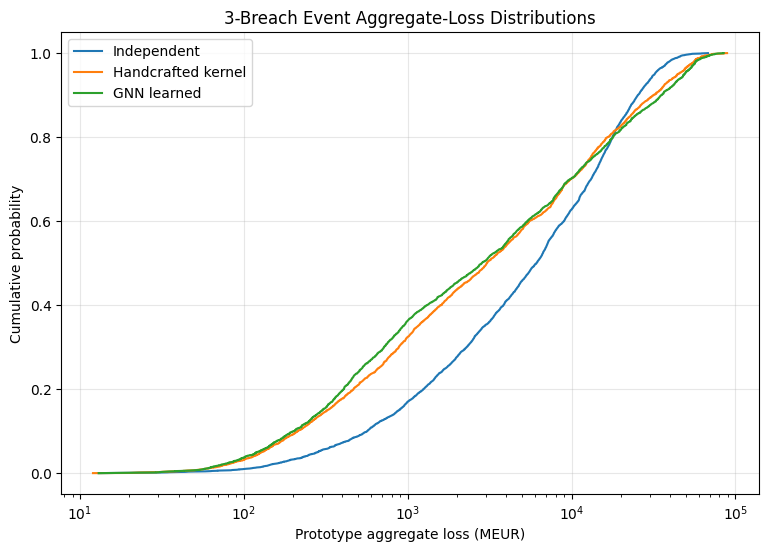

In [ ]:
 
# ECDF of prototype aggregate losses
 

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for name, losses in [
    ("Independent", loss_ind),
    ("Handcrafted kernel", loss_kernel),
    ("GNN learned", loss_gnn)
]:

    sorted_losses = np.sort(losses)
    ecdf = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)

    plt.plot(
        sorted_losses,
        ecdf,
        label=name
    )

plt.xscale("log")

plt.xlabel("Prototype aggregate loss (MEUR)")
plt.ylabel("Cumulative probability")
plt.title(
    "3-Breach Event Aggregate-Loss Distributions"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [145]:
 
# Tail probabilities
 

thresholds = [
    10000,
    25000,
    50000,
    75000
]

tail_rows = []

for name, losses in [
    ("Independent", loss_ind),
    ("Handcrafted kernel", loss_kernel),
    ("GNN learned", loss_gnn)
]:

    for threshold in thresholds:

        probability = np.mean(
            losses >= threshold
        )

        tail_rows.append({
            "generator": name,
            "threshold_MEUR": threshold,
            "P(loss >= threshold)": probability
        })

tail_table = pd.DataFrame(tail_rows)

display(
    tail_table.pivot(
        index="generator",
        columns="threshold_MEUR",
        values="P(loss >= threshold)"
    )
)

threshold_MEUR,10000,25000,50000,75000
generator,,,,
GNN learned,0.2986,0.1466,0.0454,0.0028
Handcrafted kernel,0.2994,0.1340,0.0354,0.0018
Independent,0.3728,0.1042,0.0040,0.0000


In [146]:
 
# T4000-conditioned financial-loss layer
 

# T4000 location-specific damage
t4000_damage_lookup = (
    t4000
    .groupby("breach_id")["damage_MEUR_num"]
    .median()
    .to_dict()
)

t4000_sources = np.array(
    sorted(t4000_damage_lookup.keys()),
    dtype=int
)

print("T4000 locations with usable damage:",
      len(t4000_sources))

print("Example:")
for k, v in list(t4000_damage_lookup.items())[:5]:
    print(k, v)

T4000 locations with usable damage: 268
Example:
385 23.0
395 28.0
435 1500.0
541 3.0
542 19.0


In [147]:
 
# T4000 generator coverage
 

kernel_t4000_sources = (
    set(kernel_lookup.keys())
    & set(t4000_sources)
)

gnn_t4000_sources = (
    set(gnn_transition.keys())
    & set(t4000_sources)
)

print(
    "T4000 locations:",
    len(t4000_sources)
)

print(
    "Available in handcrafted kernel:",
    len(kernel_t4000_sources)
)

print(
    "Available in GNN:",
    len(gnn_t4000_sources)
)

T4000 locations: 268
Available in handcrafted kernel: 262
Available in GNN: 259


In [148]:
 
# T4000-conditioned transition dictionaries
 

t4000_set = set(t4000_sources)

# Handcrafted kernel restricted to T4000 locations
kernel_t4000_lookup = {}

for source, info in kernel_lookup.items():

    source = int(source)

    if source not in t4000_set:
        continue

    targets = np.asarray(
        info["targets"],
        dtype=int
    )

    weights = np.asarray(
        info["weights"],
        dtype=float
    )

    mask = np.isin(targets, t4000_sources)

    targets_t = targets[mask]
    weights_t = weights[mask]

    if len(targets_t) > 0 and weights_t.sum() > 0:

        weights_t = weights_t / weights_t.sum()

        kernel_t4000_lookup[source] = {
            "targets": targets_t,
            "weights": weights_t
        }


# GNN restricted to T4000 locations
gnn_t4000_transition = {}

for source, group in candidate_pairs.groupby("breach_i"):

    source = int(source)

    if source not in t4000_set:
        continue

    targets = group["breach_j"].astype(int).to_numpy()
    probabilities = group["gnn_probability"].to_numpy()

    mask = np.isin(targets, t4000_sources)

    targets_t = targets[mask]
    probabilities_t = probabilities[mask]

    if len(targets_t) > 0 and probabilities_t.sum() > 0:

        probabilities_t = (
            probabilities_t
            / probabilities_t.sum()
        )

        gnn_t4000_transition[source] = (
            targets_t,
            probabilities_t
        )

print(
    "T4000 kernel sources:",
    len(kernel_t4000_lookup)
)

print(
    "T4000 GNN sources:",
    len(gnn_t4000_transition)
)

T4000 kernel sources: 259
T4000 GNN sources: 259


In [ ]:
 
# T4000 3-breach generators
 

def generate_restricted_kernel_events(
    transition_lookup,
    sources,
    n_events=5000,
    event_size=3,
    seed=42
):

    rng = np.random.default_rng(seed)

    sources = np.asarray(
        list(sources),
        dtype=int
    )

    events = []

    for _ in range(n_events):

        first = int(rng.choice(sources))
        event = [first]

        while len(event) < event_size:

            current = event[-1]

            if current in transition_lookup:

                targets = np.asarray(
                    transition_lookup[current]["targets"],
                    dtype=int
                )

                weights = np.asarray(
                    transition_lookup[current]["weights"],
                    dtype=float
                )

                mask = ~np.isin(
                    targets,
                    np.asarray(event)
                )

                targets = targets[mask]
                weights = weights[mask]

                if len(targets) > 0 and weights.sum() > 0:

                    weights = weights / weights.sum()

                    nxt = int(
                        rng.choice(
                            targets,
                            p=weights
                        )
                    )

                else:

                    remaining = np.array([
                        x for x in sources
                        if x not in event
                    ])

                    if len(remaining) == 0:
                        break

                    nxt = int(
                        rng.choice(remaining)
                    )

            else:

                remaining = np.array([
                    x for x in sources
                    if x not in event
                ])

                if len(remaining) == 0:
                    break

                nxt = int(
                    rng.choice(remaining)
                )

            event.append(nxt)

        if len(event) == event_size:
            events.append(event)

    return events


def generate_restricted_gnn_events(
    transition_lookup,
    sources,
    n_events=5000,
    event_size=3,
    seed=42
):

    rng = np.random.default_rng(seed)

    sources = np.asarray(
        list(sources),
        dtype=int
    )

    events = []

    for _ in range(n_events):

        first = int(rng.choice(sources))
        event = [first]

        while len(event) < event_size:

            current = event[-1]

            if current in transition_lookup:

                targets, probabilities = (
                    transition_lookup[current]
                )

                mask = ~np.isin(
                    targets,
                    np.asarray(event)
                )

                targets = targets[mask]
                probabilities = probabilities[mask]

                if (
                    len(targets) > 0
                    and probabilities.sum() > 0
                ):

                    probabilities = (
                        probabilities
                        / probabilities.sum()
                    )

                    nxt = int(
                        rng.choice(
                            targets,
                            p=probabilities
                        )
                    )

                else:

                    remaining = np.array([
                        x for x in sources
                        if x not in event
                    ])

                    if len(remaining) == 0:
                        break

                    nxt = int(
                        rng.choice(remaining)
                    )

            else:

                remaining = np.array([
                    x for x in sources
                    if x not in event
                ])

                if len(remaining) == 0:
                    break

                nxt = int(
                    rng.choice(remaining)
                )

            event.append(nxt)

        if len(event) == event_size:
            events.append(event)

    return events

In [ ]:
 
# Generate T4000 3-breach events
 

N_T4000_EVENTS = 5000

rng_ind = np.random.default_rng(4000)

t4000_independent_events = []

for _ in range(N_T4000_EVENTS):

    selected = rng_ind.choice(
        t4000_sources,
        size=3,
        replace=False
    )

    t4000_independent_events.append(
        selected.astype(int).tolist()
    )


t4000_kernel_events = generate_restricted_kernel_events(
    kernel_t4000_lookup,
    t4000_sources,
    n_events=N_T4000_EVENTS,
    event_size=3,
    seed=4001
)


t4000_gnn_events = generate_restricted_gnn_events(
    gnn_t4000_transition,
    t4000_sources,
    n_events=N_T4000_EVENTS,
    event_size=3,
    seed=4002
)


print(
    "Independent:",
    len(t4000_independent_events)
)

print(
    "Kernel:",
    len(t4000_kernel_events)
)

print(
    "GNN:",
    len(t4000_gnn_events)
)

Independent: 5000
Kernel: 5000
GNN: 5000


In [151]:
 
# T4000 aggregate loss
 

def event_losses_restricted(
    events,
    damage_lookup
):

    losses = []

    for event in events:

        values = [
            damage_lookup[int(b)]
            for b in event
            if int(b) in damage_lookup
        ]

        if len(values) == len(event):
            losses.append(
                np.sum(values)
            )

    return np.asarray(losses)


t4000_loss_ind = event_losses_restricted(
    t4000_independent_events,
    t4000_damage_lookup
)

t4000_loss_kernel = event_losses_restricted(
    t4000_kernel_events,
    t4000_damage_lookup
)

t4000_loss_gnn = event_losses_restricted(
    t4000_gnn_events,
    t4000_damage_lookup
)

print(
    "Loss observations:",
    len(t4000_loss_ind),
    len(t4000_loss_kernel),
    len(t4000_loss_gnn)
)

Loss observations: 5000 5000 5000


In [152]:
 
# T4000 financial-loss distribution
 

t4000_quantiles = [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

rows = []

for name, losses in [
    ("Independent", t4000_loss_ind),
    ("Handcrafted kernel", t4000_loss_kernel),
    ("GNN learned", t4000_loss_gnn)
]:

    for q in t4000_quantiles:

        rows.append({
            "generator": name,
            "quantile": q,
            "loss_MEUR": np.quantile(
                losses,
                q
            )
        })

t4000_loss_quantiles = (
    pd.DataFrame(rows)
    .pivot(
        index="generator",
        columns="quantile",
        values="loss_MEUR"
    )
)

display(t4000_loss_quantiles)

quantile,0.50,0.75,0.90,0.95,0.99,1.00
generator,,,,,,
GNN learned,557.0,1611.00,4203.2,7294.0,15700.9,27452.0
Handcrafted kernel,575.0,1638.25,4400.1,7339.3,15790.0,27901.0
Independent,940.5,2309.50,5331.0,8023.1,23062.0,33400.0


In [153]:
 
# T4000 loss statistics
 

t4000_loss_summary = []

for name, losses in [
    ("Independent", t4000_loss_ind),
    ("Handcrafted kernel", t4000_loss_kernel),
    ("GNN learned", t4000_loss_gnn)
]:

    t4000_loss_summary.append({
        "generator": name,
        "mean_MEUR": losses.mean(),
        "median_MEUR": np.median(losses),
        "P90_MEUR": np.quantile(losses, 0.90),
        "P95_MEUR": np.quantile(losses, 0.95),
        "P99_MEUR": np.quantile(losses, 0.99),
        "max_MEUR": losses.max()
    })

display(
    pd.DataFrame(t4000_loss_summary)
)

,generator,mean_MEUR,median_MEUR,P90_MEUR,P95_MEUR,P99_MEUR,max_MEUR
0,Independent,2126.0586,940.5,5331.0,8023.1,23062.0,33400.0
1,Handcrafted kernel,1701.1358,575.0,4400.1,7339.3,15790.0,27901.0
2,GNN learned,1673.9031,557.0,4203.2,7294.0,15700.9,27452.0


### Test whether the financial effect of dependence is stable across hazard intensity

I repeat the comparison across return periods because I do not want to assume that one dependence effect applies equally at every hazard intensity.

If the relative change in the loss distribution moves with return period, that would be another reason to condition the dependence mechanism on hazard state rather than applying one global correction.


In [ ]:
 
# Multi-return-period financial sensitivity setup
 

TEST_RPS = [
    125,
    1250,
    4000,
    40000,
    400000,
    1000000
]

RP_EVENT_N = 3000

rp_setup = []

for rp in TEST_RPS:

    rp_data = df_valid[
        df_valid["return_period"].eq(rp)
    ].copy()

    damage_lookup_rp = (
        rp_data
        .groupby("breach_id")["damage_MEUR_num"]
        .median()
        .to_dict()
    )

    rp_sources = np.array(
        sorted(damage_lookup_rp.keys()),
        dtype=int
    )

    # Handcrafted kernel coverage
    kernel_sources_rp = (
        set(rp_sources)
        & set(kernel_lookup.keys())
    )

    # GNN coverage
    gnn_sources_rp = (
        set(rp_sources)
        & set(gnn_transition.keys())
    )

    rp_setup.append({
        "return_period": rp,
        "n_locations": len(rp_sources),
        "kernel_sources": len(kernel_sources_rp),
        "gnn_sources": len(gnn_sources_rp),
        "damage_lookup": damage_lookup_rp,
        "sources": rp_sources
    })

rp_setup_df = pd.DataFrame([
    {
        "return_period": x["return_period"],
        "n_locations": x["n_locations"],
        "kernel_sources": x["kernel_sources"],
        "gnn_sources": x["gnn_sources"]
    }
    for x in rp_setup
])

display(rp_setup_df)

,return_period,n_locations,kernel_sources,gnn_sources
0,125,97,93,93
1,1250,122,117,117
2,4000,268,262,259
3,40000,266,260,257
4,400000,221,218,216
5,1000000,51,49,48


In [155]:
 
# Generate 3-breach events at each return period
 

rp_event_results = []

for setup in rp_setup:

    rp = setup["return_period"]
    sources = setup["sources"]
    damage_lookup_rp = setup["damage_lookup"]

    # ----------------------------------------
    # Independent
    # ----------------------------------------

    rng_ind = np.random.default_rng(
        10000 + rp
    )

    independent_events_rp = []

    for _ in range(RP_EVENT_N):

        selected = rng_ind.choice(
            sources,
            size=3,
            replace=False
        )

        independent_events_rp.append(
            selected.astype(int).tolist()
        )

    # ----------------------------------------
    # Handcrafted kernel
    # ----------------------------------------

    kernel_transition_rp = {}

    for source in sources:

        source = int(source)

        if source not in kernel_lookup:
            continue

        targets = np.asarray(
            kernel_lookup[source]["targets"],
            dtype=int
        )

        weights = np.asarray(
            kernel_lookup[source]["weights"],
            dtype=float
        )

        mask = np.isin(
            targets,
            sources
        )

        targets = targets[mask]
        weights = weights[mask]

        if len(targets) > 0 and weights.sum() > 0:

            weights = weights / weights.sum()

            kernel_transition_rp[source] = {
                "targets": targets,
                "weights": weights
            }

    kernel_events_rp = generate_restricted_kernel_events(
        kernel_transition_rp,
        sources,
        n_events=RP_EVENT_N,
        event_size=3,
        seed=20000 + rp
    )

    # ----------------------------------------
    # GNN
    # ----------------------------------------

    gnn_transition_rp = {}

    for source in sources:

        source = int(source)

        if source not in gnn_transition:
            continue

        targets, probabilities = (
            gnn_transition[source]
        )

        mask = np.isin(
            targets,
            sources
        )

        targets = targets[mask]
        probabilities = probabilities[mask]

        if (
            len(targets) > 0
            and probabilities.sum() > 0
        ):

            probabilities = (
                probabilities
                / probabilities.sum()
            )

            gnn_transition_rp[source] = (
                targets,
                probabilities
            )

    gnn_events_rp = generate_restricted_gnn_events(
        gnn_transition_rp,
        sources,
        n_events=RP_EVENT_N,
        event_size=3,
        seed=30000 + rp
    )

    print(
        f"T{rp}: "
        f"Independent={len(independent_events_rp)}, "
        f"Kernel={len(kernel_events_rp)}, "
        f"GNN={len(gnn_events_rp)}"
    )

    # ----------------------------------------
    # Financial losses
    # ----------------------------------------

    losses_ind = event_losses_restricted(
        independent_events_rp,
        damage_lookup_rp
    )

    losses_kernel = event_losses_restricted(
        kernel_events_rp,
        damage_lookup_rp
    )

    losses_gnn = event_losses_restricted(
        gnn_events_rp,
        damage_lookup_rp
    )

    for generator, losses in [
        ("Independent", losses_ind),
        ("Handcrafted kernel", losses_kernel),
        ("GNN learned", losses_gnn)
    ]:

        rp_event_results.append({
            "return_period": rp,
            "generator": generator,
            "n_events": len(losses),
            "mean_MEUR": np.mean(losses),
            "median_MEUR": np.median(losses),
            "P90_MEUR": np.quantile(losses, 0.90),
            "P95_MEUR": np.quantile(losses, 0.95),
            "P99_MEUR": np.quantile(losses, 0.99),
            "max_MEUR": np.max(losses)
        })


rp_loss_results = pd.DataFrame(
    rp_event_results
)

display(rp_loss_results)

T125: Independent=3000, Kernel=3000, GNN=3000
T1250: Independent=3000, Kernel=3000, GNN=3000
T4000: Independent=3000, Kernel=3000, GNN=3000
T40000: Independent=3000, Kernel=3000, GNN=3000
T400000: Independent=3000, Kernel=3000, GNN=3000
T1000000: Independent=3000, Kernel=3000, GNN=3000


,return_period,generator,n_events,mean_MEUR,median_MEUR,P90_MEUR,P95_MEUR,P99_MEUR,max_MEUR
0,125,Independent,3000,17754.627333,16028.0,34307.4,40111.50,51304.00,69000.0
1,125,Handcrafted kernel,3000,19834.601000,18400.0,40000.0,45200.00,52604.00,77000.0
2,125,GNN learned,3000,20326.701333,18900.0,41110.0,46000.00,53008.00,68000.0
3,1250,Independent,3000,25712.453333,23735.5,46300.0,54043.95,68000.00,92000.0
4,1250,Handcrafted kernel,3000,28239.352000,25340.0,56000.0,62000.00,75009.00,91000.0
5,1250,GNN learned,3000,28475.852000,26700.0,57000.0,63000.00,75000.00,89000.0
6,4000,Independent,3000,2063.656333,969.5,5423.0,8155.10,14132.00,27560.0
7,4000,Handcrafted kernel,3000,1692.431000,606.0,4240.3,7100.50,16006.45,32950.0
8,4000,GNN learned,3000,1672.917500,571.5,4500.7,7442.70,15294.00,29100.0
9,40000,Independent,3000,2633.408167,1366.5,5729.2,8542.45,24440.00,34719.0


In [ ]:
 
# P95 and P99 across hazard intensity
 

for metric in [
    "median_MEUR",
    "P90_MEUR",
    "P95_MEUR",
    "P99_MEUR"
]:

    print(f"\n===== {metric} =====")

    display(
        rp_loss_results
        .pivot(
            index="return_period",
            columns="generator",
            values=metric
        )
        .sort_index()
    )


===== median_MEUR =====


generator,GNN learned,Handcrafted kernel,Independent
return_period,,,
125,18900.0,18400.0,16028.0
1250,26700.0,25340.0,23735.5
4000,571.5,606.0,969.5
40000,801.0,905.0,1366.5
400000,1735.0,1670.5,2515.0
1000000,12970.0,12460.0,12825.0



===== P90_MEUR =====


generator,GNN learned,Handcrafted kernel,Independent
return_period,,,
125,41110.0,40000.0,34307.4
1250,57000.0,56000.0,46300.0
4000,4500.7,4240.3,5423.0
40000,5503.9,5582.9,5729.2
400000,9302.8,9461.0,10772.0
1000000,32270.0,31710.0,27509.6



===== P95_MEUR =====


generator,GNN learned,Handcrafted kernel,Independent
return_period,,,
125,46000.0,45200.0,40111.50
1250,63000.0,62000.0,54043.95
4000,7442.7,7100.5,8155.10
40000,8392.0,8141.0,8542.45
400000,16000.5,14704.2,15500.50
1000000,37800.0,41800.0,32703.00



===== P99_MEUR =====


generator,GNN learned,Handcrafted kernel,Independent
return_period,,,
125,53008.0,52604.00,51304.0
1250,75000.0,75009.00,68000.0
4000,15294.0,16006.45,14132.0
40000,19850.0,19010.00,24440.0
400000,24600.0,23411.50,25020.2
1000000,50000.0,51802.00,41505.0


In [ ]:
 
# Correct monotonicity counts
 

valid_monotonic = rp_pivot["monotonic_increasing"].notna()

n_multi_rp = valid_monotonic.sum()

n_monotonic = (
    rp_pivot.loc[
        valid_monotonic,
        "monotonic_increasing"
    ].astype(bool).sum()
)

n_non_monotonic = (
    valid_monotonic.sum()
    - n_monotonic
)

print(
    "Locations with >=2 return periods:",
    n_multi_rp
)

print(
    "Monotonic non-decreasing locations:",
    n_monotonic
)

print(
    "Non-monotonic locations:",
    n_non_monotonic
)

print(
    "Monotonic share:",
    n_monotonic / n_multi_rp
    if n_multi_rp > 0 else np.nan
)

# Non-monotonic locations only
non_monotonic_mask = (
    valid_monotonic
    & (
        rp_pivot["monotonic_increasing"] == False
    )
)

display(
    rp_pivot.loc[
        non_monotonic_mask
    ].head(20)
)

Locations with >=2 return periods: 553
Monotonic non-decreasing locations: 506
Non-monotonic locations: 47
Monotonic share: 0.9150090415913201


return_period,-9999,50,100,125,200,400,500,1000,1250,2000,...,40000,100000,125000,199999,200000,400000,928315,1000000,4000000,monotonic_increasing
breach_id,,,,,,,,,,,,,,,,,,,,,
382,NaN,NaN,NaN,NaN,12000.0,NaN,NaN,NaN,NaN,10700.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
383,NaN,NaN,NaN,NaN,2000.0,NaN,NaN,NaN,NaN,2500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
384,NaN,NaN,NaN,NaN,3100.0,NaN,NaN,NaN,NaN,3500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
393,3800.0,NaN,NaN,110.0,NaN,NaN,NaN,NaN,550.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
429,6100.0,NaN,NaN,520.0,NaN,NaN,NaN,NaN,1500.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
435,NaN,NaN,NaN,NaN,NaN,230.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,370.0,NaN,NaN,NaN,False
491,NaN,NaN,NaN,3700.0,NaN,NaN,NaN,NaN,3400.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
605,28000.0,NaN,NaN,5600.0,NaN,NaN,NaN,NaN,16000.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
692,NaN,NaN,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [166]:
 
# Quantify monotonicity violations
 

violation_rows = []

for breach_id, row in rp_pivot.iterrows():

    vals = row.drop(
        labels=["monotonic_increasing"],
        errors="ignore"
    ).dropna()

    if len(vals) < 2:
        continue

    rps = vals.index.to_numpy(dtype=float)
    damages = vals.to_numpy(dtype=float)

    diffs = np.diff(damages)

    violation_rows.append({
        "breach_id": breach_id,
        "n_return_periods": len(vals),
        "n_decreases": np.sum(diffs < 0),
        "largest_decrease_MEUR": (
            np.min(diffs)
        ),
        "max_relative_decrease": (
            np.max(
                np.where(
                    damages[:-1] > 0,
                    -diffs / damages[:-1],
                    0
                )
            )
        )
    })

violation_df = pd.DataFrame(
    violation_rows
)

display(
    violation_df.describe()
)

,breach_id,n_return_periods,n_decreases,largest_decrease_MEUR,max_relative_decrease
count,553.000000,553.000000,553.000000,553.000000,553.000000
mean,2096.632911,3.088608,0.092224,495.787523,-0.683628
std,976.857922,0.635111,0.313629,2297.493369,4.114735
min,14.000000,2.000000,0.000000,-24200.000000,-87.000000
25%,1128.000000,3.000000,0.000000,5.000000,-0.473684
50%,2304.000000,3.000000,0.000000,41.000000,-0.181818
75%,3015.000000,3.000000,0.000000,400.000000,-0.062500
max,3475.000000,4.000000,2.000000,15000.000000,0.998414


In [ ]:
 
# Common-location panel across all test return periods
 

TEST_RPS = [
    125,
    1250,
    4000,
    40000,
    400000,
    1000000
]

rp_location_sets = []

for rp in TEST_RPS:

    ids_rp = set(
        df_valid.loc[
            df_valid["return_period"].eq(rp),
            "breach_id"
        ].astype(int)
    )

    rp_location_sets.append(ids_rp)

common_locations = set.intersection(
    *rp_location_sets
)

print(
    "Locations present at ALL selected return periods:",
    len(common_locations)
)

print(
    "Example IDs:",
    sorted(common_locations)[:20]
)

Locations present at ALL selected return periods: 0
Example IDs: []


In [ ]:
 
# Relative financial effect of dependence by return period
 

rp_effects = (
    rp_loss_results
    .pivot(
        index="return_period",
        columns="generator",
        values=[
            "mean_MEUR",
            "median_MEUR",
            "P90_MEUR",
            "P95_MEUR",
            "P99_MEUR"
        ]
    )
)

effect_rows = []

for rp in TEST_RPS:

    row = {"return_period": rp}

    independent = rp_loss_results[
        (rp_loss_results["return_period"] == rp)
        &
        (rp_loss_results["generator"] == "Independent")
    ].iloc[0]

    for dependent_name in [
        "Handcrafted kernel",
        "GNN learned"
    ]:

        dependent = rp_loss_results[
            (rp_loss_results["return_period"] == rp)
            &
            (rp_loss_results["generator"] == dependent_name)
        ].iloc[0]

        prefix = (
            "kernel"
            if dependent_name == "Handcrafted kernel"
            else "gnn"
        )

        for metric in [
            "mean_MEUR",
            "median_MEUR",
            "P90_MEUR",
            "P95_MEUR",
            "P99_MEUR"
        ]:

            base = independent[metric]
            dep = dependent[metric]

            row[f"{prefix}_{metric}_relative"] = (
                (dep - base) / base
                if base != 0
                else np.nan
            )

    effect_rows.append(row)

rp_effects_df = pd.DataFrame(effect_rows)

display(rp_effects_df)

,return_period,kernel_mean_MEUR_relative,kernel_median_MEUR_relative,kernel_P90_MEUR_relative,kernel_P95_MEUR_relative,kernel_P99_MEUR_relative,gnn_mean_MEUR_relative,gnn_median_MEUR_relative,gnn_P90_MEUR_relative,gnn_P95_MEUR_relative,gnn_P99_MEUR_relative
0,125,0.117151,0.147991,0.165929,0.126859,0.025339,0.144868,0.179186,0.198284,0.146803,0.033214
1,1250,0.098275,0.067599,0.209503,0.147214,0.103074,0.107473,0.124897,0.231102,0.165718,0.102941
2,4000,-0.179887,-0.374936,-0.218090,-0.129318,0.132639,-0.189343,-0.410521,-0.170072,-0.087356,0.082225
3,40000,-0.155973,-0.337724,-0.025536,-0.046995,-0.222177,-0.174533,-0.413831,-0.039325,-0.017612,-0.187807
4,400000,-0.171310,-0.335785,-0.121704,-0.051373,-0.064296,-0.163669,-0.310139,-0.136391,0.032257,-0.016794
5,1000000,0.059952,-0.028460,0.152689,0.278170,0.248091,0.071583,0.011306,0.173045,0.155857,0.204674


In [165]:
 
# Percentage changes
 

effect_pct = rp_effects_df.copy()

for col in effect_pct.columns:
    if col != "return_period":
        effect_pct[col] *= 100

display(
    effect_pct.round(2)
)

,return_period,kernel_mean_MEUR_relative,kernel_median_MEUR_relative,kernel_P90_MEUR_relative,kernel_P95_MEUR_relative,kernel_P99_MEUR_relative,gnn_mean_MEUR_relative,gnn_median_MEUR_relative,gnn_P90_MEUR_relative,gnn_P95_MEUR_relative,gnn_P99_MEUR_relative
0,125,11.72,14.80,16.59,12.69,2.53,14.49,17.92,19.83,14.68,3.32
1,1250,9.83,6.76,20.95,14.72,10.31,10.75,12.49,23.11,16.57,10.29
2,4000,-17.99,-37.49,-21.81,-12.93,13.26,-18.93,-41.05,-17.01,-8.74,8.22
3,40000,-15.60,-33.77,-2.55,-4.70,-22.22,-17.45,-41.38,-3.93,-1.76,-18.78
4,400000,-17.13,-33.58,-12.17,-5.14,-6.43,-16.37,-31.01,-13.64,3.23,-1.68
5,1000000,6.00,-2.85,15.27,27.82,24.81,7.16,1.13,17.30,15.59,20.47


In [169]:
 
# Project paths
 

from pathlib import Path

ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
RESULTS = ROOT / "results"
FIG_DIR = RESULTS / "figures"
TABLE_DIR = RESULTS / "tables"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)



In [170]:
 
# Save learned GNN transition probabilities
 

gnn_transition_export = candidate_pairs[
    [
        "breach_i",
        "breach_j",
        "gnn_score",
        "gnn_probability"
    ]
].copy()

gnn_path = (
    TABLE_DIR
    / "gnn_transition_probabilities.csv"
)

gnn_transition_export.to_csv(
    gnn_path,
    index=False
)

print("Saved")
print("Rows:", len(gnn_transition_export))
print(
    "Source locations:",
    gnn_transition_export["breach_i"].nunique()
)

Saved
Rows: 36393
Source locations: 569


In [172]:
 
# Save handcrafted kernel probabilities
 

kernel_rows = []

for source, info in kernel_lookup.items():

    for target, weight in zip(
        info["targets"],
        info["weights"]
    ):

        kernel_rows.append({
            "breach_i": int(source),
            "breach_j": int(target),
            "kernel_probability": float(weight)
        })

kernel_export = pd.DataFrame(kernel_rows)

kernel_path = (
    TABLE_DIR
    / "handcrafted_kernel_probabilities.csv"
)

kernel_export.to_csv(
    kernel_path,
    index=False
)

print("Saved")
print("Rows:", len(kernel_export))
print(
    "Source locations:",
    kernel_export["breach_i"].nunique()
)

Saved
Rows: 21487
Source locations: 594


## Interpretation

In these exploratory scenario experiments, the dependence assumptions materially alter the aggregate-loss distributions, but the direction and magnitude of the effect vary across hazard intensities.

I therefore do not treat dependence as a universal risk-increasing or risk-reducing correction. The result instead motivates an **intensity-conditioned dependence model** whose behaviour can be checked against richer hydraulic simulations.


# BREACH-AI Prototype: Summary

## Research question

Can machine learning learn spatial and system-level dependence between flood-defence locations and use that structure to generate plausible multi-breach flood events, while preserving consequence and financial-risk characteristics?

### Important limitation

The LIWO catalogue I analysed is predominantly composed of single-breach scenarios. It therefore does not support direct empirical estimation of joint breach probabilities at the level required for a validated joint-failure model.

Instead, this prototype learns and evaluates a **consequence-based dependence proxy** and uses it to construct synthetic multi-breach events. The generated probabilities should therefore be interpreted as model outputs, not observed breach probabilities.


## Data

The live LIWO inventory contained:

- 633 current primary breach locations.
- 1,856 scenario records.
- 619 locations with scenario records.
- 610 locations with usable numeric damage observations.
- 594 locations participating in the pairwise dependence modelling.

Scenario information included return period, modeled damage, river/system context, breach characteristics, and spatial coordinates.

Return-period-specific analyses were performed where sufficient observations existed. No location was present across all six selected return periods, so cross-return-period comparisons are interpreted as intensity-stratified sensitivity analyses rather than as a balanced longitudinal panel.


## Modelling progression

1. **Independence baseline**  
   Multi-breach events sampled without spatial/system dependence.

2. **Handcrafted dependence kernel**  
   A provisional spatial/system kernel combining distance, river structure, and dike-ring structure.

3. **Tabular machine learning**  
   Random Forest models tested whether richer multi-scale neighbourhood structure could predict consequence similarity.

4. **Neural-network benchmarks**  
   MLP and GNN models were evaluated against the tabular benchmark.

5. **GNN dependence model**  
   An edge-aware GNN generated pairwise dependence scores, which were converted into normalized transition probabilities.

6. **Multi-breach generation**  
   The learned GNN was used to generate synthetic 2-, 3-, 4-, and 5-breach events.

7. **Financial-loss propagation**  
   Synthetic event sets were propagated into an aggregate-loss proxy using LIWO modelled damage.


## Key findings

### Spatial/system dependence

For 3-breach events:

- **Independent:** mean pair distance 97.36 km; same-river 5.33%; same-dike-ring 3.26%; same-system 1.50%.
- **Handcrafted kernel:** mean pair distance 17.83 km; same-river 49.62%; same-dike-ring 42.88%; same-system 30.31%.
- **GNN learned:** mean pair distance 21.94 km; same-river 43.32%; same-dike-ring 44.64%; same-system 28.68%.

The learned GNN generator therefore produced substantially more spatially and systemically coherent events than independent sampling, with event structure broadly similar to the handcrafted kernel.

These are properties of the **synthetic event sets**. They are not empirical estimates of the frequency of real simultaneous breaches.


## Predictive benchmark

For consequence-similarity prediction:

- **RF multi-scale density:** MAE = 0.1877, R² = 0.1893
- **GNN multi-scale:** MAE = 0.2150, R² = 0.0614
- **MLP multi-scale:** MAE = 0.2150, R² = 0.0501

The Random Forest is therefore the strongest predictive benchmark for the available consequence-similarity proxy.

I did not select the GNN because it maximized predictive R². Its role in the prototype is as a graph-based representation and dependence mechanism for synthetic event generation.


## Financial-loss sensitivity

For T4000-conditioned 3-breach events, the generated event sets produced different aggregate-loss distributions under the three dependence assumptions.

The key result for me is not that one dependence assumption is universally safer or riskier. It is that **changing the dependence structure changes the simulated loss distribution and its upper tail**.

These calculations are prototype aggregate-loss estimates obtained by summing location-level LIWO damage estimates. They are not physically recalculated losses from simultaneous hydraulic failures.

Across return periods, the relative effect of dependence was also not constant. The direction and magnitude varied with hazard intensity, which motivates conditioning the dependence model on hazard state rather than applying one globally fixed adjustment.


## Limitations

1. The LIWO catalogue I analysed does not provide sufficient simultaneous-breach observations for direct empirical estimation of joint breach probabilities.
2. Consequence similarity is therefore used as a dependence proxy.
3. The handcrafted kernel parameters are provisional modelling choices.
4. The GNN evaluation is transductive because the full graph is available during message passing.
5. Aggregate-loss calculations use existing single-breach damage estimates and therefore do not reproduce hydraulic interaction effects during simultaneous failures.
6. Return-period datasets have heterogeneous spatial coverage.
7. The generated-event distributions are synthetic and require validation against richer hydraulic simulations or observed/system-level event data.


## Proposed research extension

This prototype motivates a next step in which the learned probabilistic structure is coupled back to the physical flood system:

```text
Existing hydraulic scenarios
        ↓
Hydraulic / defence-system graph
        ↓
Probabilistic dependence learning
        ↓
Higher-order multi-breach scenario generation
        ↓
Hydraulic consequence model / surrogate
        ↓
Portfolio damage and financial loss
        ↓
Climate-state conditioning
        ↓
Insurability maps and tipping points
```

The main extensions I would investigate are:

- richer hydraulic and defence-system connectivity;
- intensity-conditioned dependence learning;
- higher-order probabilistic event generation;
- uncertainty quantification and calibration;
- validation against hydraulic simulations;
- integration with KNMI/IPCC climate states;
- translation from scenario sets to financial loss distributions and long-term insurability.

The important change from the current prototype is that the generated events would ultimately be checked and constrained by hydraulic consequences rather than relying only on single-breach loss proxies.


## Prototype conclusion

The experiments show that a spatial/system dependence mechanism can change the structure of generated multi-breach events and, in turn, the simulated aggregate-loss distribution.

They also show where the current approach breaks down: the LIWO catalogue does not give enough simultaneous-breach observations to estimate joint probabilities directly, pairwise generation becomes increasingly incomplete for larger events, and the current financial layer is based on single-breach damage proxies.

These limitations are what lead me toward a higher-order, hybrid AI–hydraulic framework rather than treating the current generator as a finished flood-risk model.
